# Clinical outcomes after VATS for primary spontaneous pneumothorax

This notebook presents a reproducible observational analysis of operative indication, perioperative course, and recurrence after VATS wedge resection with pleural abrasion.

The workflow is designed around a clinical question, but it emphasizes statistical discipline. It separates description, group comparison, outcome association, time-to-event analysis, prediction, sensitivity analysis, and prospective planning.

## Questions addressed

1. How do patients operated for recurrent pneumothorax and prolonged air leak differ at presentation and during the postoperative course?
2. Which perioperative characteristics are associated with ipsilateral recurrence during follow-up?
3. Does failure to visualize a bleb or bulla remain associated with recurrence after adjustment?
4. How well can recurrence be discriminated from routinely available variables under cross-validation?
5. How sensitive is the main recurrence estimate to the handling of unknown operative findings?

Association is not interpreted as causation. Prediction results are internally evaluated and are not presented as clinical validation.

In [1]:
from pathlib import Path
import json
import platform
import warnings

import numpy as np
import pandas as pd
import scipy
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from statsmodels.duration.hazard_regression import PHReg
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 20260915
rng = np.random.default_rng(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
TABLE_DIR = PROJECT_ROOT / "tables"
for folder in [DATA_DIR, FIGURE_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:0.3f}")

print("Random seed", SEED)
print("Python", platform.python_version())

Random seed 20260915
Python 3.11.15


## Statistical helpers

Continuous outcomes are described with medians and interquartile ranges because postoperative durations are usually right-skewed. The Mann-Whitney U test is paired with rank-biserial correlation and a bootstrap interval for the median difference.

Binary comparisons include odds ratios and Cramer's V. Benjamini-Hochberg correction is applied within each exploratory test family. Time-to-event analyses use Kaplan-Meier estimates, log-rank tests, and Cox proportional hazards regression.

In [2]:
def expit(value):
    value = np.asarray(value)
    return 1 / (1 + np.exp(-value))


def fmt_p(value):
    if pd.isna(value):
        return "NA"
    return "<0.001" if value < 0.001 else f"{value:.3f}"


def median_iqr(values):
    values = pd.Series(values).dropna().to_numpy()
    q1, median, q3 = np.quantile(values, [0.25, 0.50, 0.75])
    return f"{median:.1f} [{q1:.1f}, {q3:.1f}]"


def count_percent(values, condition=1):
    series = pd.Series(values).dropna()
    count = int((series == condition).sum())
    return f"{count} ({100 * count / len(series):.1f}%)"


def rank_biserial(x, y):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    u = stats.mannwhitneyu(x, y, alternative="two-sided").statistic
    return 2 * u / (len(x) * len(y)) - 1


def bootstrap_two_sample(x, y, statistic, n_boot=1500, seed=SEED):
    x = pd.Series(x).dropna().to_numpy()
    y = pd.Series(y).dropna().to_numpy()
    local_rng = np.random.default_rng(seed)
    estimates = np.empty(n_boot)
    for index in range(n_boot):
        xb = local_rng.choice(x, len(x), replace=True)
        yb = local_rng.choice(y, len(y), replace=True)
        estimates[index] = statistic(xb, yb)
    return np.quantile(estimates, [0.025, 0.975])


def compare_continuous(frame, variable, group="indication"):
    recurrence = frame.loc[frame[group].eq("recurrence"), variable].dropna()
    pal = frame.loc[frame[group].eq("prolonged_air_leak"), variable].dropna()
    test = stats.mannwhitneyu(recurrence, pal, alternative="two-sided")
    median_difference = recurrence.median() - pal.median()
    ci_low, ci_high = bootstrap_two_sample(
        recurrence,
        pal,
        lambda x, y: np.median(x) - np.median(y),
        seed=SEED + len(variable),
    )
    return {
        "variable": variable,
        "recurrence": median_iqr(recurrence),
        "prolonged_air_leak": median_iqr(pal),
        "median_difference": median_difference,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "rank_biserial_r": rank_biserial(recurrence, pal),
        "p_value": test.pvalue,
        "n_recurrence": len(recurrence),
        "n_prolonged_air_leak": len(pal),
    }


def categorical_comparison(frame, variable, outcome="indication_recurrence"):
    analysis = frame[[variable, outcome]].dropna()
    table = pd.crosstab(analysis[variable], analysis[outcome])
    chi2, chi_p, _, expected = stats.chi2_contingency(table)
    if table.shape == (2, 2) and (expected < 5).any():
        _, p_value = stats.fisher_exact(table)
        test_name = "Fisher exact"
    else:
        p_value = chi_p
        test_name = "Chi-square"
    n = table.to_numpy().sum()
    phi2 = max(0, chi2 / n)
    denominator = max(1, min(table.shape[0] - 1, table.shape[1] - 1))
    cramers_v = np.sqrt(phi2 / denominator)
    return test_name, p_value, cramers_v, len(analysis)


def odds_ratio_2x2(exposure, outcome):
    frame = pd.DataFrame({"exposure": exposure, "outcome": outcome}).dropna()
    table = pd.crosstab(frame["exposure"], frame["outcome"]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    a = table.loc[1, 1] + 0.5
    b = table.loc[1, 0] + 0.5
    c = table.loc[0, 1] + 0.5
    d = table.loc[0, 0] + 0.5
    estimate = (a * d) / (b * c)
    standard_error = np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
    return estimate, np.exp(np.log(estimate) - 1.96 * standard_error), np.exp(
        np.log(estimate) + 1.96 * standard_error
    )


def bootstrap_auc(y_true, scores, n_boot=1500, seed=SEED):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    local_rng = np.random.default_rng(seed)
    estimates = []
    for _ in range(n_boot):
        index = local_rng.integers(0, len(y_true), len(y_true))
        if len(np.unique(y_true[index])) < 2:
            continue
        estimates.append(roc_auc_score(y_true[index], scores[index]))
    return np.quantile(estimates, [0.025, 0.975])


def regression_table(result, names, exponentiate=True):
    confidence = np.asarray(result.conf_int())
    estimates = np.asarray(result.params)
    p_values = np.asarray(result.pvalues)
    if exponentiate:
        estimates = np.exp(estimates)
        confidence = np.exp(confidence)
    return pd.DataFrame(
        {
            "term": names,
            "estimate": estimates,
            "ci_low": confidence[:, 0],
            "ci_high": confidence[:, 1],
            "p_value": p_values,
        }
    )

## Generate the cohort

The cohort has one row per operation. Ages are restricted to 18 through 39 years. Exact operation dates, names, record numbers, institutions, and free-text notes are not generated.

Known relationships are encoded so that model behavior can be checked. Ipsilateral recurrence is more common when no bleb or bulla is visualized, in smokers, and after operations performed for recurrent disease. These are design choices, not estimates from a real population.

In [3]:
N = 650

indication_recurrence = rng.binomial(1, 0.73, N)
indication = np.where(indication_recurrence == 1, "recurrence", "prolonged_air_leak")
age_years = stats.truncnorm.rvs(
    (18 - 24.8) / 5.4,
    (39 - 24.8) / 5.4,
    loc=24.8,
    scale=5.4,
    size=N,
    random_state=rng,
).round(1)
sex_male = rng.binomial(1, 0.84, N)
sex = np.where(sex_male == 1, "male", "female")
side_right = rng.binomial(1, 0.56, N)
side = np.where(side_right == 1, "right", "left")

smoking_probability = expit(-0.15 + 0.30 * sex_male + 0.045 * (age_years - 25))
smoking_history = rng.binomial(1, smoking_probability)
pack_years_true = np.where(
    smoking_history == 1,
    np.clip(rng.gamma(2.0, 3.6, N), 0.2, 36),
    0,
).round(1)
pack_years = pack_years_true.astype(float)
pack_years[(smoking_history == 1) & (rng.random(N) < 0.035)] = np.nan

previous_tube_probability = expit(-0.35 + 1.25 * indication_recurrence)
previous_tube_thoracostomy = rng.binomial(1, previous_tube_probability)
tube_first_episode = rng.binomial(1, expit(0.20 + 0.90 * indication_recurrence))
tube_current_admission = rng.binomial(1, expit(1.55 - 0.25 * indication_recurrence))

symptomatic = rng.binomial(1, 0.94, N)
chest_pain = symptomatic * rng.binomial(1, 0.63, N)
dyspnea = symptomatic * rng.binomial(1, 0.55, N)

bleb_probability = expit(1.05 + 0.20 * indication_recurrence + 0.25 * smoking_history)
bleb_visualized_true = rng.binomial(1, bleb_probability)
bleb_status = np.where(bleb_visualized_true == 1, "visualized", "not_visualized").astype(object)
bleb_status[rng.random(N) < 0.035] = "unknown"

multiple_wedge = rng.binomial(
    1, expit(-1.75 + 0.55 * bleb_visualized_true + 0.20 * indication_recurrence)
)

previous_episode_pattern = np.full(N, "first_episode", dtype=object)
recurrence_indices = np.where(indication_recurrence == 1)[0]
previous_episode_pattern[recurrence_indices] = rng.choice(
    ["ipsilateral", "contralateral", "bilateral_history"],
    size=len(recurrence_indices),
    p=[0.74, 0.21, 0.05],
)

air_leak_days = np.where(
    rng.random(N) < expit(0.45 - 0.18 * indication_recurrence),
    0,
    1 + rng.negative_binomial(1.3, 0.58, N),
)
air_leak_days += rng.binomial(1, 0.13 + 0.05 * (1 - indication_recurrence), N)
rare_air_leak = rng.random(N) < 0.012
air_leak_days[rare_air_leak] += rng.integers(8, 24, rare_air_leak.sum())
air_leak_days = np.clip(air_leak_days, 0, 35).astype(int)

postop_complication = rng.binomial(
    1, expit(-3.65 + 0.17 * air_leak_days + 0.35 * (1 - bleb_visualized_true))
)
chest_tube_days = np.ceil(
    2.0
    + 0.78 * air_leak_days
    + 0.35 * previous_tube_thoracostomy
    + rng.gamma(1.3, 0.65, N)
).astype(int)
chest_tube_days = np.clip(chest_tube_days, 1, 35)

length_of_stay_days = np.ceil(
    2.2
    + 0.34 * air_leak_days
    + 0.42 * previous_tube_thoracostomy
    + 0.70 * postop_complication
    + rng.gamma(1.4, 0.60, N)
).astype(int)
length_of_stay_days = np.clip(length_of_stay_days, 2, 18)

follow_up_months = np.clip(12 + rng.gamma(2.2, 11.5, N), 12, 84).round(1)
age_z = (age_years - 25) / 5
recurrence_linear_predictor = (
    0.85 * indication_recurrence
    + 1.25 * (1 - bleb_visualized_true)
    + 0.75 * smoking_history
    + 0.35 * multiple_wedge
    + 0.35 * previous_tube_thoracostomy
    + 0.50 * postop_complication
    + 0.05 * air_leak_days
    - 0.25 * age_z
)
monthly_hazard = 0.0015 * np.exp(recurrence_linear_predictor)
latent_recurrence_time = rng.exponential(1 / monthly_hazard)
ipsilateral_recurrence = (latent_recurrence_time <= follow_up_months).astype(int)
time_to_event_months = np.minimum(latent_recurrence_time, follow_up_months).round(2)

contralateral_recurrence = rng.binomial(
    1, expit(-3.15 + 0.20 * smoking_history + 0.15 * indication_recurrence)
)
recurrence_tube_required = ipsilateral_recurrence * rng.binomial(1, 0.48, N)
reoperation_after_recurrence = ipsilateral_recurrence * rng.binomial(1, 0.27, N)

surgery_period = rng.choice(
    ["2018-2019", "2020-2021", "2022-2023", "2024-2025"],
    size=N,
    p=[0.21, 0.24, 0.28, 0.27],
)

df = pd.DataFrame(
    {
        "synthetic_id": [f"PSP{number:04d}" for number in range(1, N + 1)],
        "surgery_period": surgery_period,
        "age_years": age_years,
        "sex": sex,
        "side": side,
        "indication": indication,
        "symptomatic": symptomatic,
        "chest_pain": chest_pain,
        "dyspnea": dyspnea,
        "smoking_history": smoking_history,
        "pack_years": pack_years,
        "previous_tube_thoracostomy": previous_tube_thoracostomy,
        "tube_first_episode": tube_first_episode,
        "tube_current_admission": tube_current_admission,
        "previous_episode_pattern": previous_episode_pattern,
        "bleb_status": bleb_status,
        "multiple_wedge": multiple_wedge,
        "postop_air_leak_days": air_leak_days,
        "chest_tube_days": chest_tube_days,
        "length_of_stay_days": length_of_stay_days,
        "postop_complication": postop_complication,
        "follow_up_months": follow_up_months,
        "time_to_event_months": time_to_event_months,
        "ipsilateral_recurrence": ipsilateral_recurrence,
        "contralateral_recurrence": contralateral_recurrence,
        "recurrence_tube_required": recurrence_tube_required,
        "reoperation_after_recurrence": reoperation_after_recurrence,
    }
)

df.to_csv(DATA_DIR / "synthetic_psp_vats_cohort.csv", index=False)
df.head()

,synthetic_id,surgery_period,age_years,sex,side,indication,symptomatic,chest_pain,dyspnea,smoking_history,pack_years,previous_tube_thoracostomy,tube_first_episode,tube_current_admission,previous_episode_pattern,bleb_status,multiple_wedge,postop_air_leak_days,chest_tube_days,length_of_stay_days,postop_complication,follow_up_months,time_to_event_months,ipsilateral_recurrence,contralateral_recurrence,recurrence_tube_required,reoperation_after_recurrence
0,PSP0001,2024-2025,19.600,male,right,prolonged_air_leak,1,1,1,1,8.400,0,1,1,first_episode,visualized,0,0,3,3,0,29.600,29.600,0,0,0,0
1,PSP0002,2022-2023,19.700,male,left,recurrence,1,1,1,0,0.000,0,1,1,ipsilateral,not_visualized,0,0,3,4,0,24.900,24.900,0,1,0,0
2,PSP0003,2020-2021,36.900,male,left,recurrence,1,1,0,1,4.100,1,1,1,ipsilateral,unknown,0,1,4,4,0,28.900,28.900,0,0,0,0
3,PSP0004,2020-2021,26.100,female,left,recurrence,1,1,0,0,0.000,1,0,1,ipsilateral,not_visualized,1,0,3,3,0,33.400,33.400,0,1,0,0
4,PSP0005,2022-2023,35.600,male,right,recurrence,1,1,1,1,5.300,1,1,1,bilateral_history,visualized,1,0,3,5,0,37.100,37.100,0,0,0,0


## Data dictionary

Binary fields use 1 for present and 0 for absent. Follow-up time is the observed time to ipsilateral recurrence or censoring.

In [4]:
data_dictionary = pd.DataFrame(
    [
        ("synthetic_id", "Generated record identifier", "text"),
        ("surgery_period", "Two-year calendar band", "categorical"),
        ("age_years", "Age at operation", "years"),
        ("sex", "Recorded sex", "categorical"),
        ("side", "Operated hemithorax", "categorical"),
        ("indication", "Recurrent pneumothorax or prolonged air leak", "categorical"),
        ("symptomatic", "Any presenting symptom", "binary"),
        ("chest_pain", "Chest pain at presentation", "binary"),
        ("dyspnea", "Dyspnea at presentation", "binary"),
        ("smoking_history", "History of smoking", "binary"),
        ("pack_years", "Cumulative tobacco exposure", "pack-years"),
        ("previous_tube_thoracostomy", "Tube thoracostomy during an earlier admission", "binary"),
        ("tube_first_episode", "Tube treatment at first episode", "binary"),
        ("tube_current_admission", "Tube treatment during operative admission", "binary"),
        ("previous_episode_pattern", "Relationship to prior pneumothorax episode", "categorical"),
        ("bleb_status", "Macroscopic bleb or bulla finding", "categorical"),
        ("multiple_wedge", "More than one wedge resection area", "binary"),
        ("postop_air_leak_days", "Postoperative air-leak duration", "days"),
        ("chest_tube_days", "Time to postoperative chest-tube removal", "days"),
        ("length_of_stay_days", "Postoperative hospital stay", "days"),
        ("postop_complication", "Recorded postoperative complication", "binary"),
        ("follow_up_months", "Available postoperative follow-up", "months"),
        ("time_to_event_months", "Time to ipsilateral recurrence or censoring", "months"),
        ("ipsilateral_recurrence", "Recurrence on the operated side", "binary"),
        ("contralateral_recurrence", "Recurrence on the opposite side", "binary"),
        ("recurrence_tube_required", "Tube required after ipsilateral recurrence", "binary"),
        ("reoperation_after_recurrence", "Reoperation after ipsilateral recurrence", "binary"),
    ],
    columns=["variable", "definition", "unit_or_type"],
)
data_dictionary.to_csv(DATA_DIR / "data_dictionary.csv", index=False)
data_dictionary

,variable,definition,unit_or_type
0,synthetic_id,Generated record identifier,text
1,surgery_period,Two-year calendar band,categorical
2,age_years,Age at operation,years
3,sex,Recorded sex,categorical
4,side,Operated hemithorax,categorical
5,indication,Recurrent pneumothorax or prolonged air leak,categorical
6,symptomatic,Any presenting symptom,binary
7,chest_pain,Chest pain at presentation,binary
8,dyspnea,Dyspnea at presentation,binary
9,smoking_history,History of smoking,binary


## Validation checks

Logical checks are run before any hypothesis test. They cover identifiers, eligibility ranges, nonnegative durations, event timing, and dependent variables.

In [5]:
validation_checks = pd.DataFrame(
    [
        ("Expected row count", len(df) == N, len(df)),
        ("Unique record identifiers", df["synthetic_id"].is_unique, df["synthetic_id"].nunique()),
        ("Age between 18 and 39", df["age_years"].between(18, 39).all(), int((~df["age_years"].between(18, 39)).sum())),
        ("Nonnegative postoperative durations", (df[["postop_air_leak_days", "chest_tube_days", "length_of_stay_days"]] >= 0).all().all(), int((df[["postop_air_leak_days", "chest_tube_days", "length_of_stay_days"]] < 0).sum().sum())),
        ("Event time does not exceed follow-up", (df["time_to_event_months"] <= df["follow_up_months"] + 0.01).all(), int((df["time_to_event_months"] > df["follow_up_months"] + 0.01).sum())),
        ("Recurrence treatment requires recurrence", ((df["recurrence_tube_required"] <= df["ipsilateral_recurrence"]) & (df["reoperation_after_recurrence"] <= df["ipsilateral_recurrence"])).all(), int(((df["recurrence_tube_required"] > df["ipsilateral_recurrence"]) | (df["reoperation_after_recurrence"] > df["ipsilateral_recurrence"])).sum())),
        ("No smoking implies zero pack-years", (df.loc[df["smoking_history"].eq(0), "pack_years"].fillna(0) == 0).all(), int((df.loc[df["smoking_history"].eq(0), "pack_years"].fillna(0) != 0).sum())),
    ],
    columns=["check", "passed", "observed"],
)
validation_checks.to_csv(TABLE_DIR / "00_validation_checks.csv", index=False)
validation_checks

,check,passed,observed
0,Expected row count,True,650
1,Unique record identifiers,True,650
2,Age between 18 and 39,True,0
3,Nonnegative postoperative durations,True,0
4,Event time does not exceed follow-up,True,0
5,Recurrence treatment requires recurrence,True,0
6,No smoking implies zero pack-years,True,0


In [6]:
missingness = pd.DataFrame(
    {
        "variable": df.columns,
        "missing_n": df.isna().sum().to_numpy(),
        "missing_percent": 100 * df.isna().mean().to_numpy(),
    }
).query("missing_n > 0").reset_index(drop=True)
missingness.to_csv(TABLE_DIR / "01_missingness.csv", index=False)
missingness

,variable,missing_n,missing_percent
0,pack_years,12,1.846


## Cohort description

The two indication groups are described without treating baseline p-values as a test of successful randomization. This is an observational design. The table shows the population available for later adjusted analyses.

In [7]:
profile_specs = [
    ("Age, years", "continuous", "age_years", None),
    ("Male sex", "binary", "sex", "male"),
    ("Right side", "binary", "side", "right"),
    ("Smoking history", "binary", "smoking_history", 1),
    ("Pack-years among smokers", "continuous_smokers", "pack_years", None),
    ("Previous tube thoracostomy", "binary", "previous_tube_thoracostomy", 1),
    ("Tube during current admission", "binary", "tube_current_admission", 1),
    ("Bleb or bulla visualized", "binary", "bleb_status", "visualized"),
    ("Multiple wedge resection", "binary", "multiple_wedge", 1),
    ("Follow-up, months", "continuous", "follow_up_months", None),
    ("Ipsilateral recurrence", "binary", "ipsilateral_recurrence", 1),
]

profile_rows = []
for label, kind, variable, condition in profile_specs:
    row = {"measure": label}
    for group_label, subset in [
        ("overall", df),
        ("recurrence_indication", df.loc[df["indication"].eq("recurrence")]),
        ("prolonged_air_leak_indication", df.loc[df["indication"].eq("prolonged_air_leak")]),
    ]:
        values = subset[variable]
        if kind == "continuous":
            row[group_label] = median_iqr(values)
        elif kind == "continuous_smokers":
            row[group_label] = median_iqr(subset.loc[subset["smoking_history"].eq(1), variable])
        else:
            row[group_label] = count_percent(values, condition)
    profile_rows.append(row)

cohort_profile = pd.DataFrame(profile_rows)
cohort_profile.to_csv(TABLE_DIR / "02_cohort_profile.csv", index=False)
cohort_profile

,measure,overall,recurrence_indication,prolonged_air_leak_indication
0,"Age, years","25.5 [22.4, 29.0]","25.4 [22.5, 28.9]","25.9 [22.4, 29.0]"
1,Male sex,537 (82.6%),403 (82.8%),134 (82.2%)
2,Right side,356 (54.8%),267 (54.8%),89 (54.6%)
3,Smoking history,344 (52.9%),262 (53.8%),82 (50.3%)
4,Pack-years among smokers,"6.4 [4.2, 10.0]","6.4 [4.2, 10.2]","6.4 [4.3, 9.4]"
5,Previous tube thoracostomy,392 (60.3%),326 (66.9%),66 (40.5%)
6,Tube during current admission,530 (81.5%),391 (80.3%),139 (85.3%)
7,Bleb or bulla visualized,502 (77.2%),381 (78.2%),121 (74.2%)
8,Multiple wedge resection,157 (24.2%),120 (24.6%),37 (22.7%)
9,"Follow-up, months","33.3 [25.1, 45.9]","34.0 [25.3, 45.9]","32.5 [24.3, 45.0]"


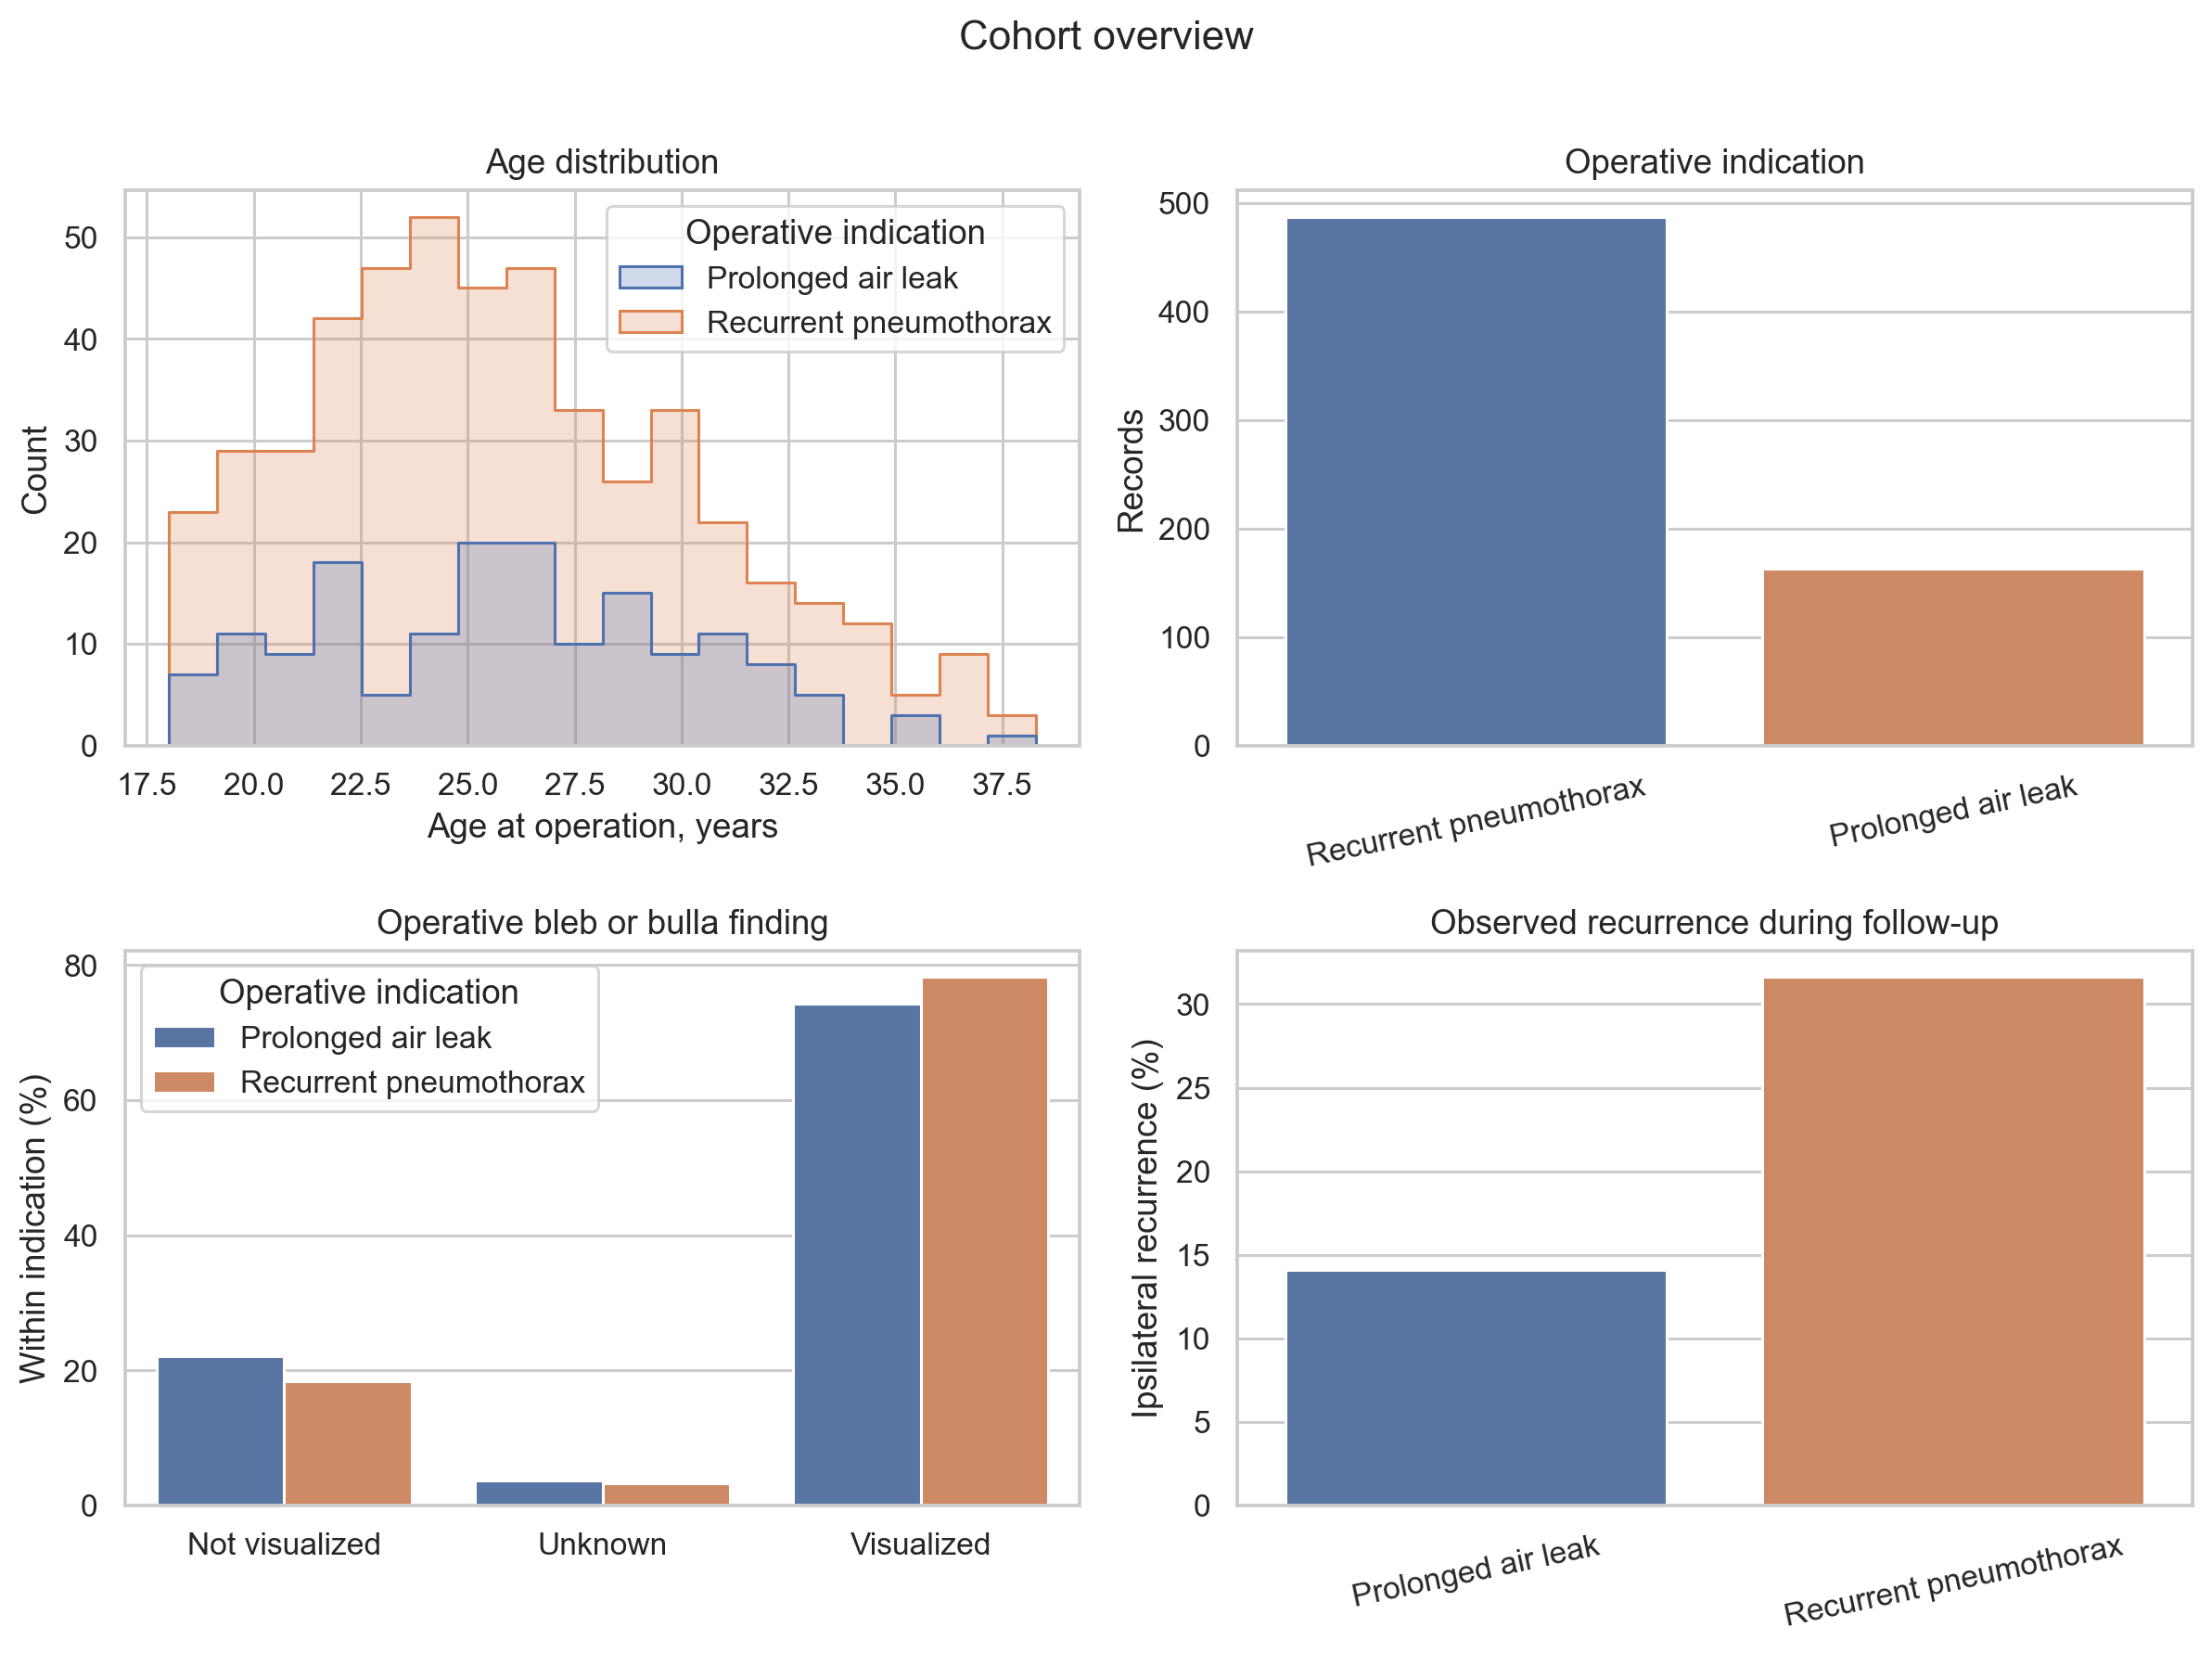

In [8]:
overview_df = df.assign(
    indication_label=df["indication"].map(
        {"recurrence": "Recurrent pneumothorax", "prolonged_air_leak": "Prolonged air leak"}
    ),
    bleb_label=df["bleb_status"].map(
        {"visualized": "Visualized", "not_visualized": "Not visualized", "unknown": "Unknown"}
    ),
)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.histplot(data=overview_df, x="age_years", hue="indication_label", bins=18, element="step", common_norm=False, ax=axes[0, 0])
axes[0, 0].set_xlabel("Age at operation, years")
axes[0, 0].set_title("Age distribution")
axes[0, 0].get_legend().set_title("Operative indication")

indication_counts = overview_df["indication_label"].value_counts().rename_axis("indication").reset_index(name="count")
sns.barplot(data=indication_counts, x="indication", y="count", hue="indication", legend=False, ax=axes[0, 1])
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Records")
axes[0, 1].set_title("Operative indication")
axes[0, 1].tick_params(axis="x", rotation=12)

bleb_counts = pd.crosstab(overview_df["bleb_label"], overview_df["indication_label"], normalize="columns").mul(100).reset_index().melt(id_vars="bleb_label", var_name="indication", value_name="percent")
sns.barplot(data=bleb_counts, x="bleb_label", y="percent", hue="indication", ax=axes[1, 0])
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Within indication (%)")
axes[1, 0].set_title("Operative bleb or bulla finding")
axes[1, 0].get_legend().set_title("Operative indication")

recurrence_rates = overview_df.groupby("indication_label")["ipsilateral_recurrence"].mean().mul(100).rename("percent").reset_index()
sns.barplot(data=recurrence_rates, x="indication_label", y="percent", hue="indication_label", legend=False, ax=axes[1, 1])
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Ipsilateral recurrence (%)")
axes[1, 1].set_title("Observed recurrence during follow-up")
axes[1, 1].tick_params(axis="x", rotation=12)

fig.suptitle("Cohort overview", y=1.01)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_cohort_overview.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "01_cohort_overview.png"), alt="Cohort overview showing age, operative indication, bleb status, and recurrence."))

## Postoperative course by operative indication

Postoperative air leak, chest tube duration, and hospital stay are count-like and right-skewed. Medians and interquartile ranges describe their typical values. The Mann-Whitney U test compares the full distributions without assuming normality. Rank-biserial correlation adds an effect-size measure. Positive values indicate larger values in the recurrent-pneumothorax indication group.

The bootstrap interval describes uncertainty around the median difference. Adjusted q-values control the false-discovery rate within this three-outcome family.

In [9]:
postoperative_labels = {
    "postop_air_leak_days": "Postoperative air leak, days",
    "chest_tube_days": "Chest tube duration, days",
    "length_of_stay_days": "Hospital stay, days",
}

postoperative_results = pd.DataFrame(
    [compare_continuous(df, variable) for variable in postoperative_labels]
)
postoperative_results.insert(
    1, "outcome", postoperative_results["variable"].map(postoperative_labels)
)
postoperative_results["q_value"] = multipletests(
    postoperative_results["p_value"], method="fdr_bh"
)[1]
postoperative_results.to_csv(TABLE_DIR / "03_postoperative_outcomes.csv", index=False)
postoperative_results[
    [
        "outcome",
        "recurrence",
        "prolonged_air_leak",
        "median_difference",
        "ci_low",
        "ci_high",
        "rank_biserial_r",
        "p_value",
        "q_value",
    ]
]

,outcome,recurrence,prolonged_air_leak,median_difference,ci_low,ci_high,rank_biserial_r,p_value,q_value
0,"Postoperative air leak, days","0.0 [0.0, 1.0]","0.0 [0.0, 2.0]",0.000,-1.000,1.000,-0.014,0.769,0.993
1,"Chest tube duration, days","4.0 [3.0, 5.0]","4.0 [3.0, 5.0]",0.000,0.000,0.000,0.000,0.993,0.993
2,"Hospital stay, days","4.0 [4.0, 5.0]","4.0 [3.0, 4.0]",0.000,0.000,0.000,0.053,0.280,0.840


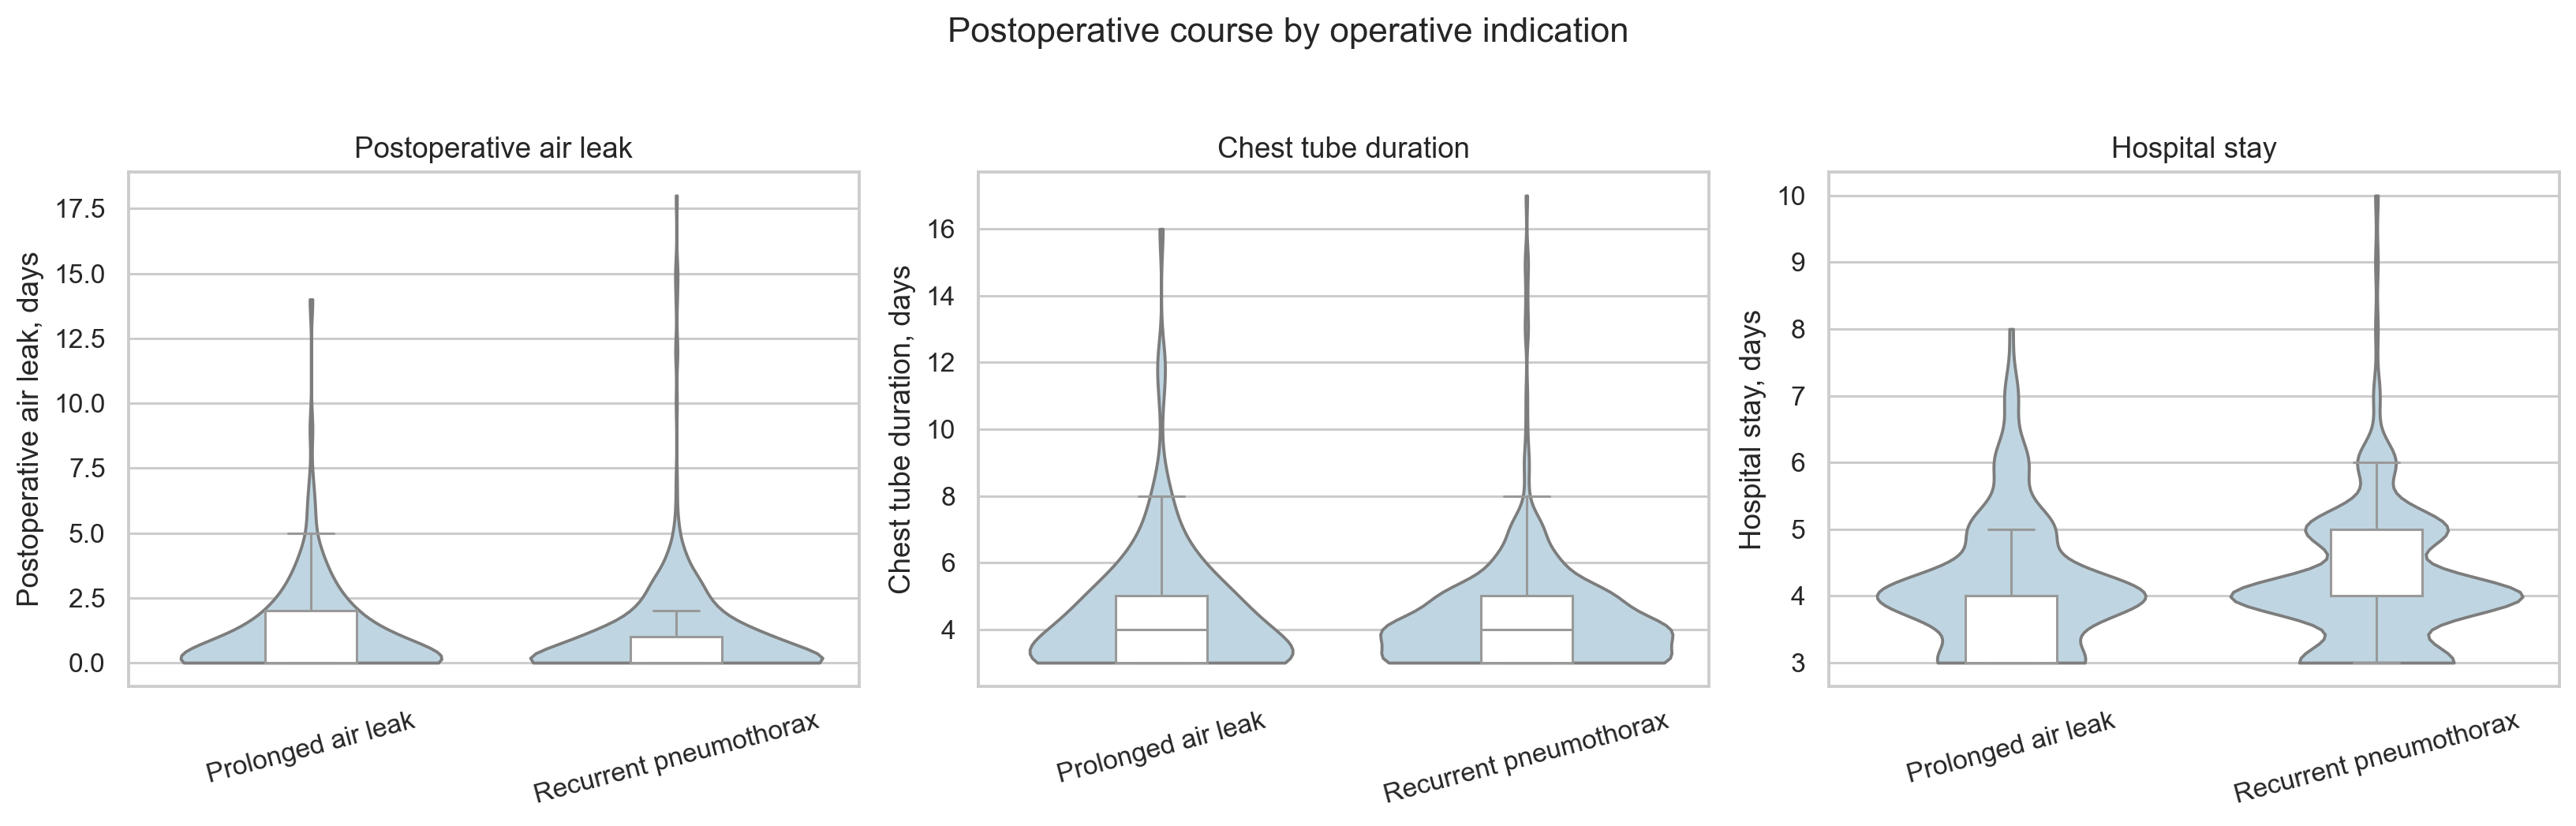

In [10]:
plot_frame = df.assign(
    indication_label=df["indication"].map(
        {"recurrence": "Recurrent pneumothorax", "prolonged_air_leak": "Prolonged air leak"}
    )
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for axis, (variable, label) in zip(axes, postoperative_labels.items()):
    sns.violinplot(
        data=plot_frame,
        x="indication_label",
        y=variable,
        inner=None,
        cut=0,
        color="#b9d8e8",
        ax=axis,
    )
    sns.boxplot(
        data=plot_frame,
        x="indication_label",
        y=variable,
        width=0.25,
        showfliers=False,
        color="white",
        ax=axis,
    )
    axis.set_xlabel("")
    axis.set_ylabel(label)
    axis.tick_params(axis="x", rotation=15)
    axis.set_title(label.replace(", days", ""))

fig.suptitle("Postoperative course by operative indication", y=1.03)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_postoperative_outcomes.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "02_postoperative_outcomes.png"), alt="Violin and box plots of postoperative outcomes by operative indication."))

## Categorical characteristics by operative indication

Chi-square tests assess association when expected cell counts are adequate. Fisher's exact test is reserved for sparse two-by-two tables. Cramer's V summarizes association strength. Odds ratios compare the odds of the recurrent-pneumothorax indication between exposed and unexposed groups.

Operative bleb status is evaluated among records with a known finding. These comparisons are exploratory and do not imply that indication was caused by any single characteristic.

In [11]:
df = df.assign(
    indication_recurrence=df["indication"].eq("recurrence").astype(int),
    sex_male=df["sex"].eq("male").astype(int),
    side_right=df["side"].eq("right").astype(int),
    bleb_not_visualized=np.where(
        df["bleb_status"].eq("unknown"), np.nan, df["bleb_status"].eq("not_visualized").astype(int)
    ),
    bleb_unknown=df["bleb_status"].eq("unknown").astype(int),
    age_5y=(df["age_years"] - 25) / 5,
)

categorical_specs = {
    "sex_male": "Male sex",
    "side_right": "Right side",
    "smoking_history": "Smoking history",
    "previous_tube_thoracostomy": "Previous tube thoracostomy",
    "tube_current_admission": "Tube during current admission",
    "bleb_not_visualized": "Bleb or bulla not visualized",
    "multiple_wedge": "Multiple wedge resection",
    "postop_complication": "Postoperative complication",
}

categorical_rows = []
for variable, label in categorical_specs.items():
    test_name, p_value, cramers_v, n_complete = categorical_comparison(df, variable)
    odds_ratio, ci_low, ci_high = odds_ratio_2x2(df[variable], df["indication_recurrence"])
    categorical_rows.append(
        {
            "characteristic": label,
            "variable": variable,
            "n_complete": n_complete,
            "test": test_name,
            "odds_ratio": odds_ratio,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "cramers_v": cramers_v,
            "p_value": p_value,
        }
    )

categorical_results = pd.DataFrame(categorical_rows)
categorical_results["q_value"] = multipletests(
    categorical_results["p_value"], method="fdr_bh"
)[1]
categorical_results.to_csv(TABLE_DIR / "04_categorical_comparisons.csv", index=False)
categorical_results

,characteristic,variable,n_complete,test,odds_ratio,ci_low,ci_high,cramers_v,p_value,q_value
0,Male sex,sex_male,650,Chi-square,1.047,0.660,1.663,0.002,0.969,1.000
1,Right side,side_right,650,Chi-square,1.010,0.708,1.441,0.000,1.000,1.000
2,Smoking history,smoking_history,650,Chi-square,1.150,0.807,1.639,0.027,0.495,0.990
3,Previous tube thoracostomy,previous_tube_thoracostomy,650,Chi-square,2.964,2.059,4.267,0.231,0.000,0.000
4,Tube during current admission,tube_current_admission,650,Chi-square,0.713,0.439,1.156,0.051,0.192,0.769
5,Bleb or bulla not visualized,bleb_not_visualized,628,Chi-square,0.790,0.511,1.220,0.037,0.357,0.953
6,Multiple wedge resection,multiple_wedge,650,Chi-square,1.106,0.728,1.681,0.016,0.692,1.000
7,Postoperative complication,postop_complication,650,Chi-square,0.945,0.352,2.542,0.000,1.000,1.000


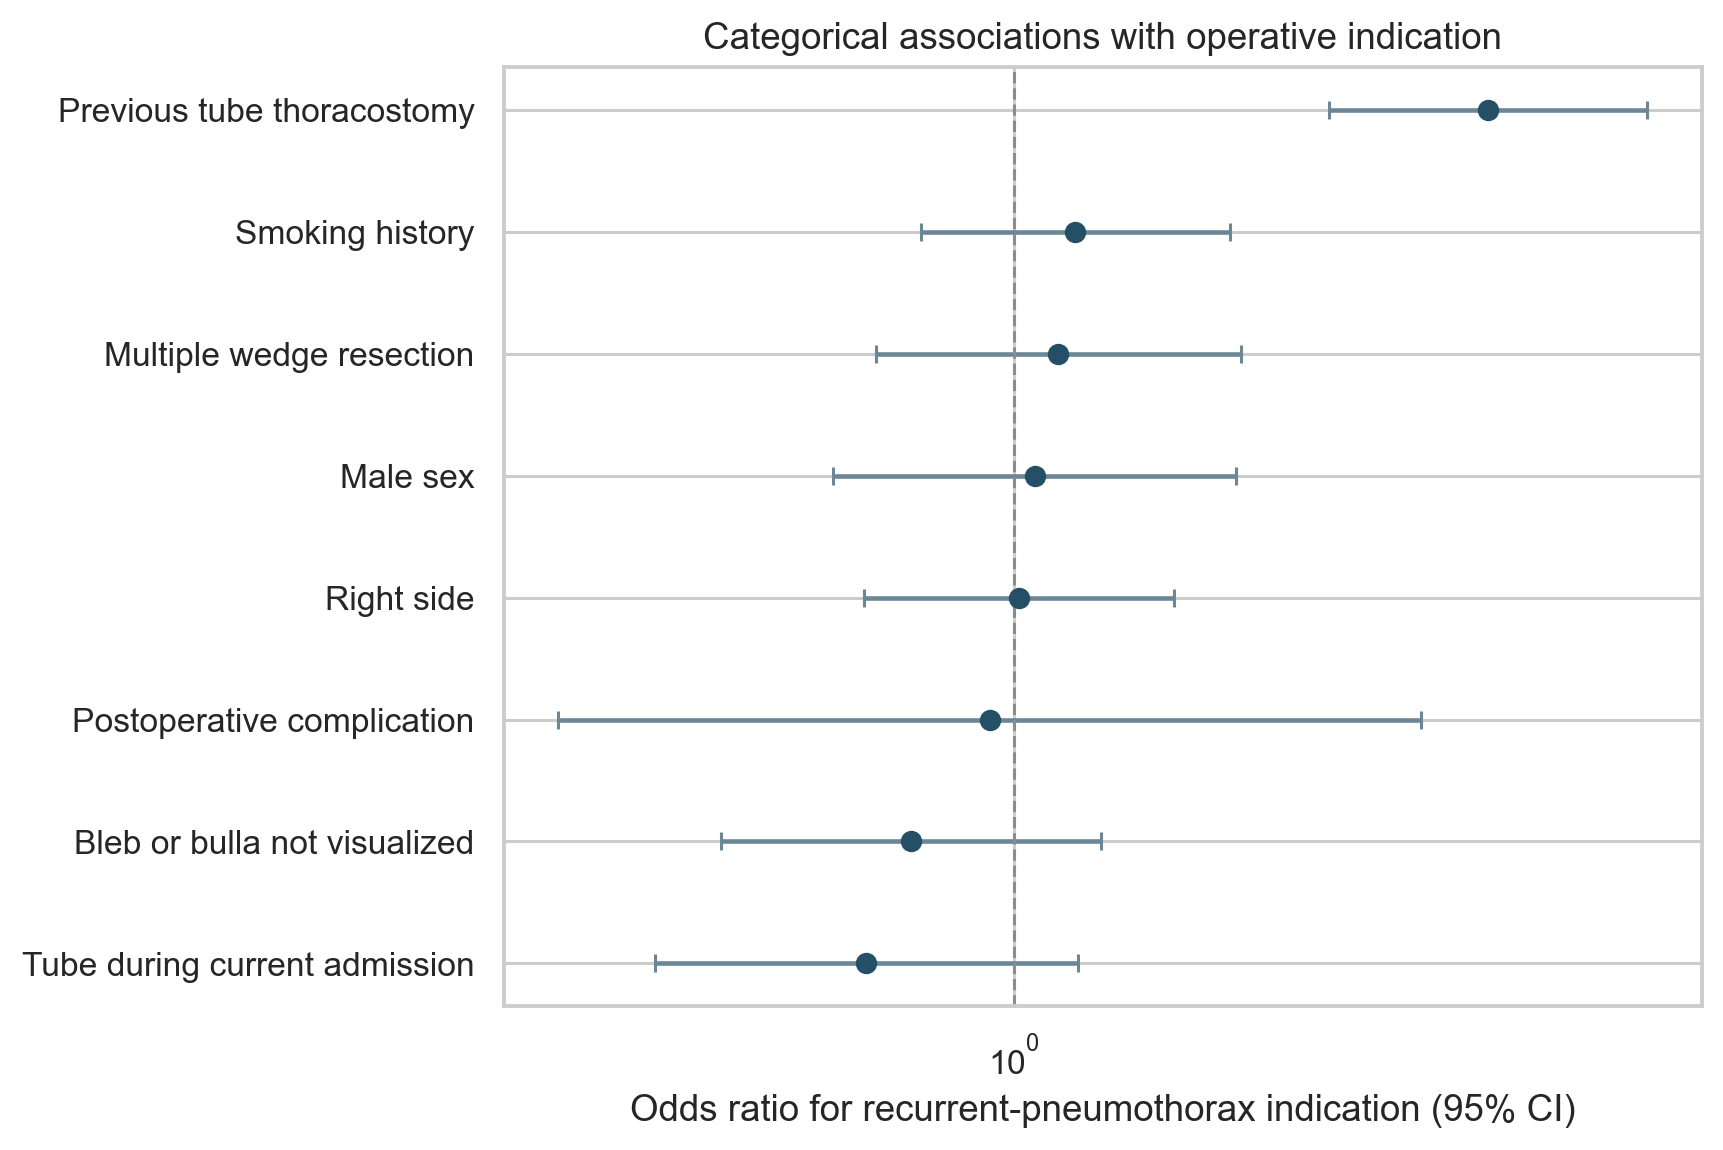

In [12]:
forest = categorical_results.sort_values("odds_ratio").reset_index(drop=True)
positions = np.arange(len(forest))

fig, axis = plt.subplots(figsize=(8, 5.4))
axis.errorbar(
    forest["odds_ratio"],
    positions,
    xerr=[forest["odds_ratio"] - forest["ci_low"], forest["ci_high"] - forest["odds_ratio"]],
    fmt="o",
    color="#244f66",
    ecolor="#6b8796",
    capsize=3,
)
axis.axvline(1, color="#8c8c8c", linestyle="--", linewidth=1)
axis.set_xscale("log")
axis.set_yticks(positions, forest["characteristic"])
axis.set_xlabel("Odds ratio for recurrent-pneumothorax indication (95% CI)")
axis.set_title("Categorical associations with operative indication")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_categorical_effects.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "03_categorical_effects.png"), alt="Forest plot of odds ratios for operative indication."))

## Ipsilateral recurrence during follow-up

A simple recurrence percentage ignores unequal follow-up. Kaplan-Meier analysis uses both recurrence and censoring times to estimate recurrence-free probability. The log-rank test compares the full curves, not a single time point.

The main descriptive contrast concerns whether a bleb or bulla was visualized during surgery. Unknown operative findings remain visible in the summary table but are excluded from the two-curve comparison.

In [13]:
def recurrence_summary(frame, grouping, label_map=None):
    rows = []
    for level, subset in frame.groupby(grouping, observed=True):
        events = int(subset["ipsilateral_recurrence"].sum())
        total = len(subset)
        ci_low, ci_high = proportion_confint(events, total, method="wilson")
        rows.append(
            {
                "grouping": grouping,
                "level": label_map.get(level, level) if label_map else level,
                "n": total,
                "events": events,
                "recurrence_percent": 100 * events / total,
                "ci_low_percent": 100 * ci_low,
                "ci_high_percent": 100 * ci_high,
                "median_follow_up_months": subset["follow_up_months"].median(),
            }
        )
    return rows


recurrence_rows = []
recurrence_rows.extend(
    recurrence_summary(
        df,
        "indication",
        {"recurrence": "Recurrent pneumothorax", "prolonged_air_leak": "Prolonged air leak"},
    )
)
recurrence_rows.extend(
    recurrence_summary(
        df,
        "bleb_status",
        {
            "visualized": "Bleb or bulla visualized",
            "not_visualized": "Not visualized",
            "unknown": "Unknown",
        },
    )
)
recurrence_table = pd.DataFrame(recurrence_rows)
recurrence_table.to_csv(TABLE_DIR / "05_recurrence_summary.csv", index=False)
recurrence_table

,grouping,level,n,events,recurrence_percent,ci_low_percent,ci_high_percent,median_follow_up_months
0,indication,Prolonged air leak,163,23,14.110,9.590,20.283,32.500
1,indication,Recurrent pneumothorax,487,154,31.622,27.650,35.882,34.000
2,bleb_status,Not visualized,126,54,42.857,34.554,51.583,30.600
3,bleb_status,Unknown,22,7,31.818,16.361,52.681,29.550
4,bleb_status,Bleb or bulla visualized,502,116,23.108,19.633,26.991,34.100


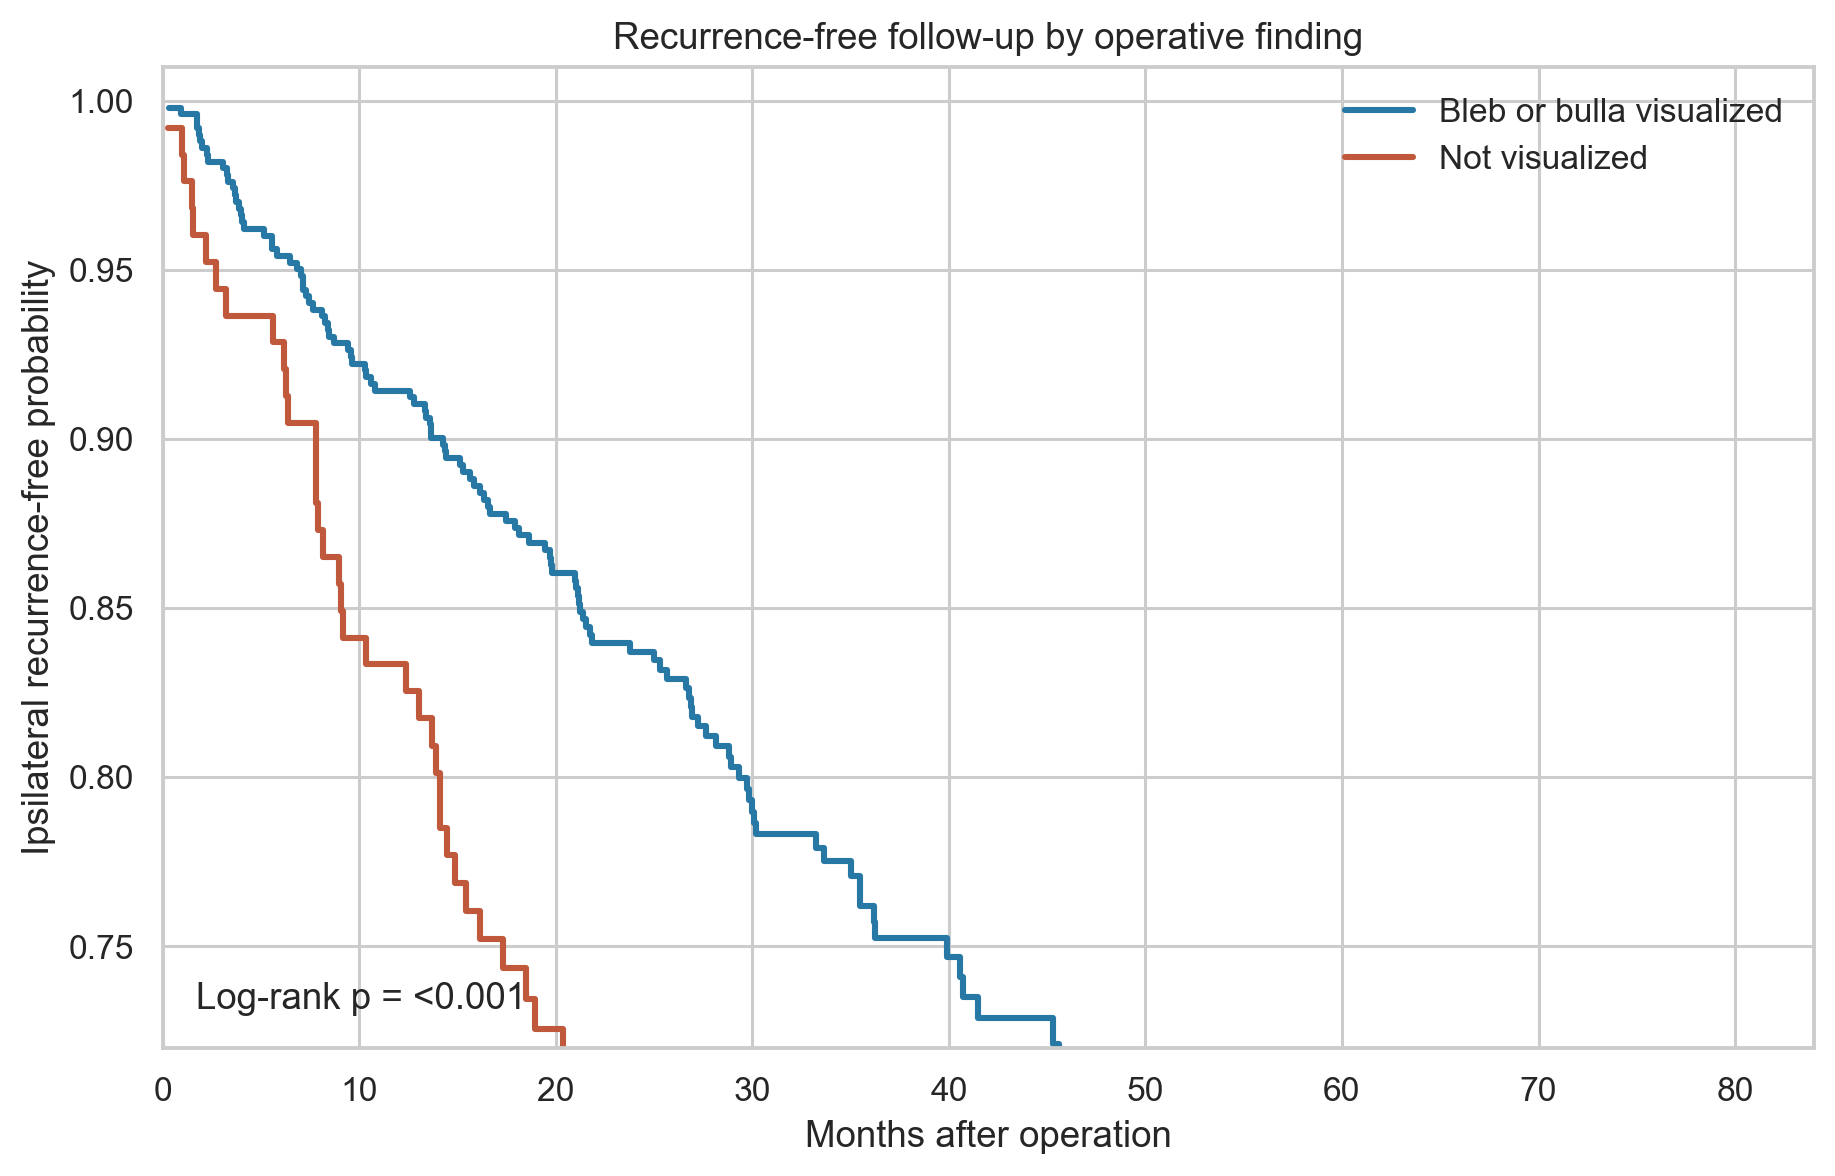

In [14]:
known_bleb = df.loc[df["bleb_status"].ne("unknown")].copy()
survival_curves = {}
for level, label in [
    ("visualized", "Bleb or bulla visualized"),
    ("not_visualized", "Not visualized"),
]:
    subset = known_bleb.loc[known_bleb["bleb_status"].eq(level)]
    survival_curves[label] = SurvfuncRight(
        subset["time_to_event_months"], subset["ipsilateral_recurrence"]
    )

logrank_statistic, logrank_p = survdiff(
    known_bleb["time_to_event_months"],
    known_bleb["ipsilateral_recurrence"],
    known_bleb["bleb_status"].eq("not_visualized").astype(int),
)
pd.DataFrame(
    [{"comparison": "Bleb or bulla finding", "chi_square": logrank_statistic, "p_value": logrank_p}]
).to_csv(TABLE_DIR / "05b_logrank_test.csv", index=False)

fig, axis = plt.subplots(figsize=(8.5, 5.5))
colors = ["#2878a5", "#c0593c"]
for (label, curve), color in zip(survival_curves.items(), colors):
    axis.step(curve.surv_times, curve.surv_prob, where="post", label=label, color=color, linewidth=2)
axis.set_ylim(0.72, 1.01)
axis.set_xlim(0, df["follow_up_months"].max())
axis.set_xlabel("Months after operation")
axis.set_ylabel("Ipsilateral recurrence-free probability")
axis.set_title("Recurrence-free follow-up by operative finding")
axis.text(0.02, 0.04, f"Log-rank p = {fmt_p(logrank_p)}", transform=axis.transAxes)
axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_kaplan_meier_bleb.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "04_kaplan_meier_bleb.png"), alt="Kaplan-Meier curves for ipsilateral recurrence-free follow-up by operative bleb finding."))

## Adjusted time-to-recurrence model

The Cox model estimates hazard ratios while respecting censoring. Covariates were chosen before model fitting to represent indication, operative finding, age, sex, smoking history, previous tube thoracostomy, and wedge count. Age is scaled to five-year increments for interpretation.

An unknown-finding indicator keeps incomplete operative documentation in the primary model. Hazard ratios above 1 indicate a higher instantaneous recurrence rate during follow-up. The estimate is an adjusted association, not a treatment effect.

In [15]:
cox_variables = [
    "indication_recurrence",
    "bleb_not_visualized",
    "bleb_unknown",
    "age_5y",
    "sex_male",
    "smoking_history",
    "previous_tube_thoracostomy",
    "multiple_wedge",
]
cox_names = [
    "Recurrent-pneumothorax indication",
    "Bleb or bulla not visualized",
    "Operative finding unknown",
    "Age, per 5 years",
    "Male sex",
    "Smoking history",
    "Previous tube thoracostomy",
    "Multiple wedge resection",
]

cox_frame = df.copy()
cox_frame["bleb_not_visualized"] = cox_frame["bleb_not_visualized"].fillna(0)
cox_model = PHReg(
    cox_frame["time_to_event_months"],
    cox_frame[cox_variables].astype(float),
    status=cox_frame["ipsilateral_recurrence"],
    ties="efron",
)
cox_result = cox_model.fit()
cox_table = regression_table(cox_result, cox_names, exponentiate=True)
cox_table.rename(columns={"estimate": "hazard_ratio"}, inplace=True)
cox_table.to_csv(TABLE_DIR / "06_cox_model.csv", index=False)
cox_table

,term,hazard_ratio,ci_low,ci_high,p_value
0,Recurrent-pneumothorax indication,2.562,1.637,4.009,0.000
1,Bleb or bulla not visualized,2.716,1.955,3.773,0.000
2,Operative finding unknown,1.341,0.621,2.896,0.455
3,"Age, per 5 years",0.857,0.724,1.014,0.072
4,Male sex,1.102,0.730,1.664,0.643
5,Smoking history,1.954,1.422,2.685,0.000
6,Previous tube thoracostomy,1.349,0.972,1.871,0.073
7,Multiple wedge resection,1.438,1.033,2.002,0.031


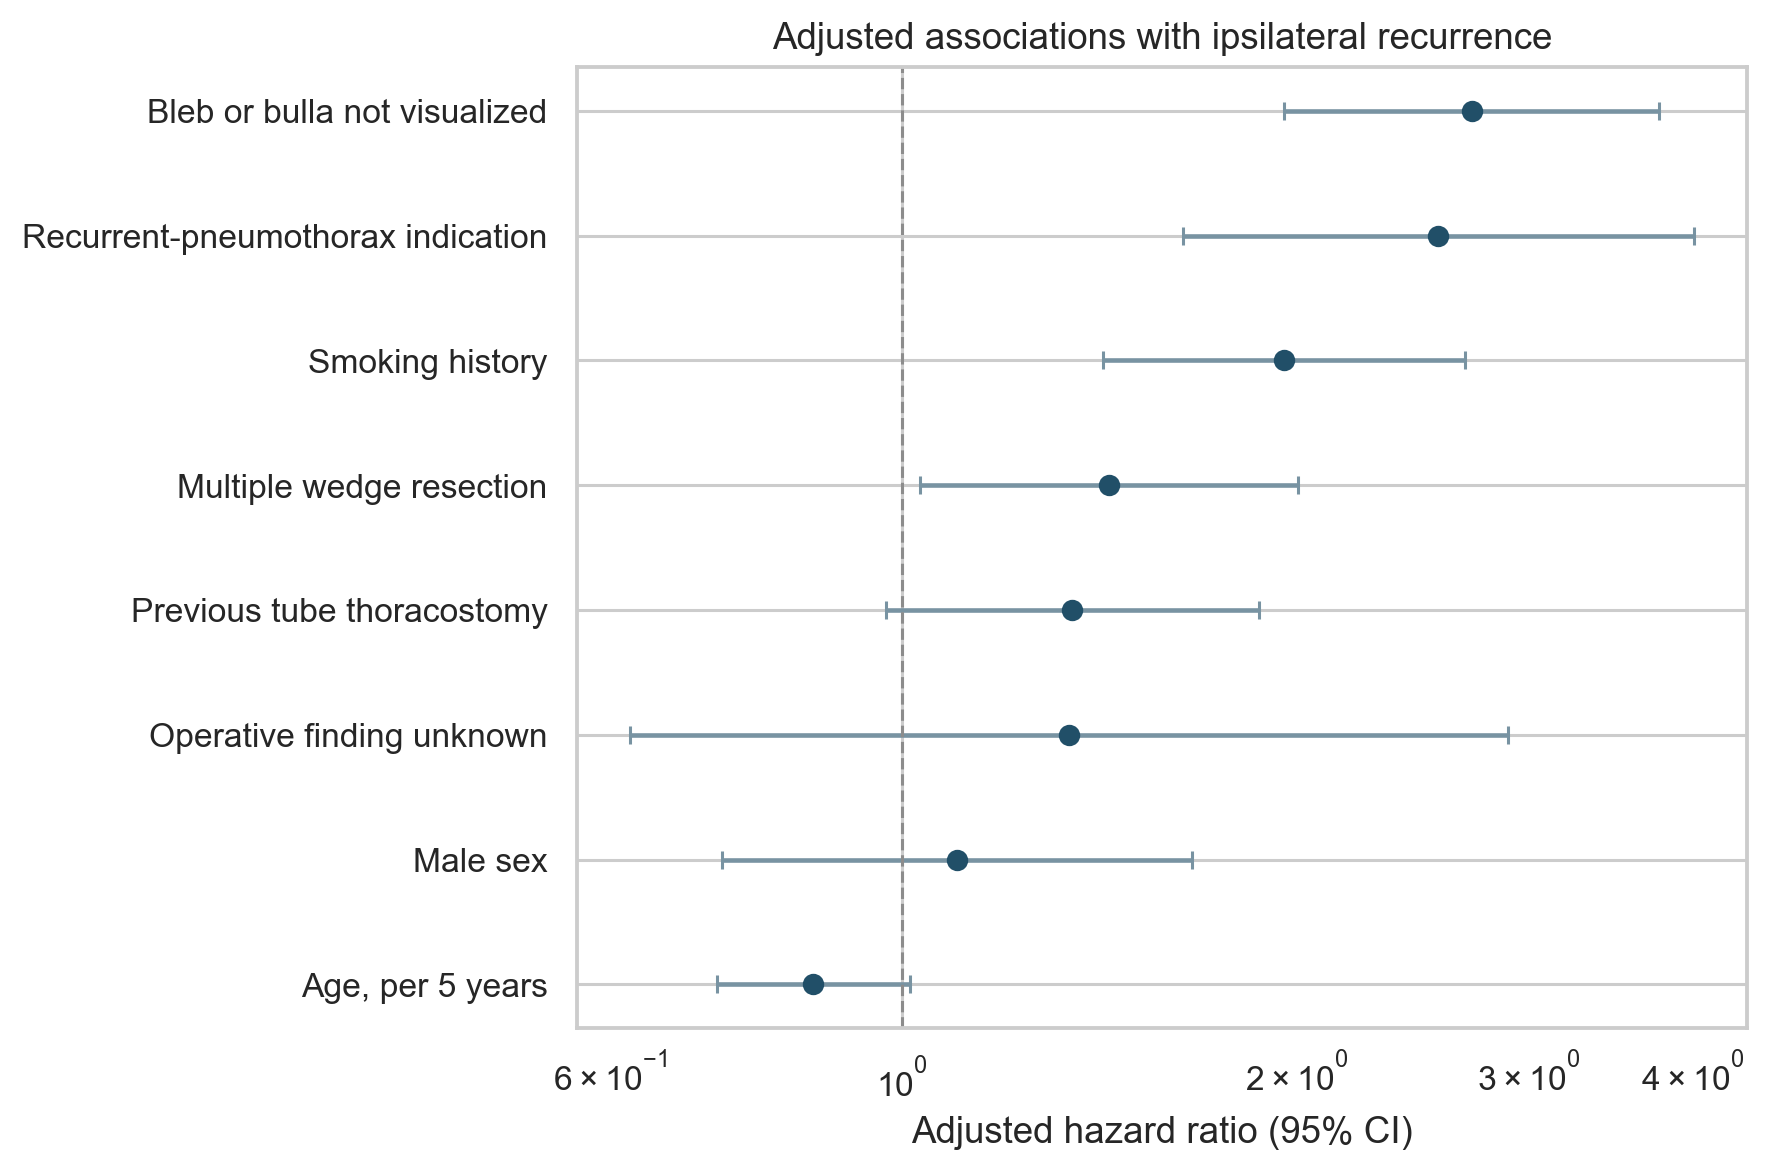

In [16]:
forest = cox_table.sort_values("hazard_ratio").reset_index(drop=True)
positions = np.arange(len(forest))

fig, axis = plt.subplots(figsize=(8.2, 5.5))
axis.errorbar(
    forest["hazard_ratio"],
    positions,
    xerr=[forest["hazard_ratio"] - forest["ci_low"], forest["ci_high"] - forest["hazard_ratio"]],
    fmt="o",
    color="#214f68",
    ecolor="#7893a2",
    capsize=3,
)
axis.axvline(1, color="#8c8c8c", linestyle="--", linewidth=1)
axis.set_xscale("log")
axis.set_yticks(positions, forest["term"])
axis.set_xlabel("Adjusted hazard ratio (95% CI)")
axis.set_title("Adjusted associations with ipsilateral recurrence")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_cox_forest.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "05_cox_forest.png"), alt="Forest plot of adjusted Cox proportional hazards model."))

### Proportional-hazards check

For each model term, Schoenfeld residuals are correlated with log event time. A strong time trend would question the proportional-hazards assumption. The test is a diagnostic aid and is considered alongside the number of events and graphical judgment.

In [17]:
schoenfeld = np.asarray(cox_result.schoenfeld_residuals)
event_mask = cox_frame["ipsilateral_recurrence"].eq(1).to_numpy()
event_times = np.sort(np.log(cox_frame.loc[event_mask, "time_to_event_months"].to_numpy()))

ph_rows = []
for index, term in enumerate(cox_names):
    residual = schoenfeld[event_mask, index]
    valid = np.isfinite(residual) & np.isfinite(event_times)
    rho, p_value = stats.spearmanr(event_times[valid], residual[valid])
    ph_rows.append({"term": term, "spearman_rho": rho, "p_value": p_value, "n_events": int(valid.sum())})

ph_checks = pd.DataFrame(ph_rows)
ph_checks["q_value"] = multipletests(ph_checks["p_value"], method="fdr_bh")[1]
ph_checks.to_csv(TABLE_DIR / "07_proportional_hazards_checks.csv", index=False)
ph_checks

,term,spearman_rho,p_value,n_events,q_value
0,Recurrent-pneumothorax indication,-0.096,0.205,177,0.546
1,Bleb or bulla not visualized,0.097,0.197,177,0.546
2,Operative finding unknown,0.108,0.154,177,0.546
3,"Age, per 5 years",0.012,0.872,177,0.967
4,Male sex,0.046,0.541,177,0.866
5,Smoking history,-0.055,0.465,177,0.866
6,Previous tube thoracostomy,-0.016,0.829,177,0.967
7,Multiple wedge resection,-0.003,0.967,177,0.967


## Cross-validated recurrence prediction

This section asks a prediction question that is distinct from the explanatory Cox model. Logistic models estimate recurrence within 24 months. Records censored before 24 months without recurrence are excluded because their 24-month status is unknown. Every prediction is generated for a record that was not used to fit that fold's model.

The baseline model uses age, sex, indication, smoking history, and pack-years. The perioperative model adds tube history, operative finding, wedge count, postoperative air leak, and complications. Five-fold stratified cross-validation is used for out-of-fold performance. Discrimination is summarized with ROC AUC and average precision. Calibration is summarized with the Brier score, calibration intercept, and calibration slope.

In [18]:
prediction_eligible = (
    (df["ipsilateral_recurrence"].eq(1) & df["time_to_event_months"].le(24))
    | df["follow_up_months"].ge(24)
)
prediction_df = df.loc[prediction_eligible].copy()
y = (
    prediction_df["ipsilateral_recurrence"].eq(1)
    & prediction_df["time_to_event_months"].le(24)
).astype(int)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

feature_sets = {
    "Baseline": {
        "numeric": ["age_years", "pack_years"],
        "categorical": ["sex", "indication", "smoking_history"],
    },
    "Perioperative": {
        "numeric": ["age_years", "pack_years", "postop_air_leak_days"],
        "categorical": [
            "sex",
            "indication",
            "smoking_history",
            "previous_tube_thoracostomy",
            "bleb_status",
            "multiple_wedge",
            "postop_complication",
        ],
    },
}


def make_prediction_pipeline(numeric, categorical):
    preprocessing = ColumnTransformer(
        [
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
                        ("scale", StandardScaler()),
                    ]
                ),
                numeric,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("one_hot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")),
                    ]
                ),
                categorical,
            ),
        ]
    )
    return Pipeline(
        [
            ("preprocessing", preprocessing),
            ("model", LogisticRegression(max_iter=3000, penalty="l2")),
        ]
    )


prediction_scores = {}
performance_rows = []
for model_index, (model_name, specification) in enumerate(feature_sets.items()):
    features = specification["numeric"] + specification["categorical"]
    model = make_prediction_pipeline(specification["numeric"], specification["categorical"])
    probability = cross_val_predict(
        model, prediction_df[features], y, cv=cv, method="predict_proba", n_jobs=None
    )[:, 1]
    prediction_scores[model_name] = probability
    auc = roc_auc_score(y, probability)
    auc_low, auc_high = bootstrap_auc(y, probability, seed=SEED + model_index)
    clipped = np.clip(probability, 1e-6, 1 - 1e-6)
    linear_predictor = np.log(clipped / (1 - clipped))
    calibration_model = sm.GLM(y, sm.add_constant(linear_predictor), family=sm.families.Binomial()).fit()
    performance_rows.append(
        {
            "model": model_name,
            "roc_auc": auc,
            "auc_ci_low": auc_low,
            "auc_ci_high": auc_high,
            "average_precision": average_precision_score(y, probability),
            "brier_score": brier_score_loss(y, probability),
            "calibration_intercept": calibration_model.params.iloc[0],
            "calibration_slope": calibration_model.params.iloc[1],
            "events": int(y.sum()),
            "records": len(y),
        }
    )

prediction_performance = pd.DataFrame(performance_rows)
prediction_performance.to_csv(TABLE_DIR / "08_prediction_performance.csv", index=False)
prediction_performance

,model,roc_auc,auc_ci_low,auc_ci_high,average_precision,brier_score,calibration_intercept,calibration_slope,events,records
0,Baseline,0.618,0.560,0.672,0.340,0.175,-0.252,0.766,125,528
1,Perioperative,0.684,0.627,0.737,0.429,0.165,-0.144,0.856,125,528


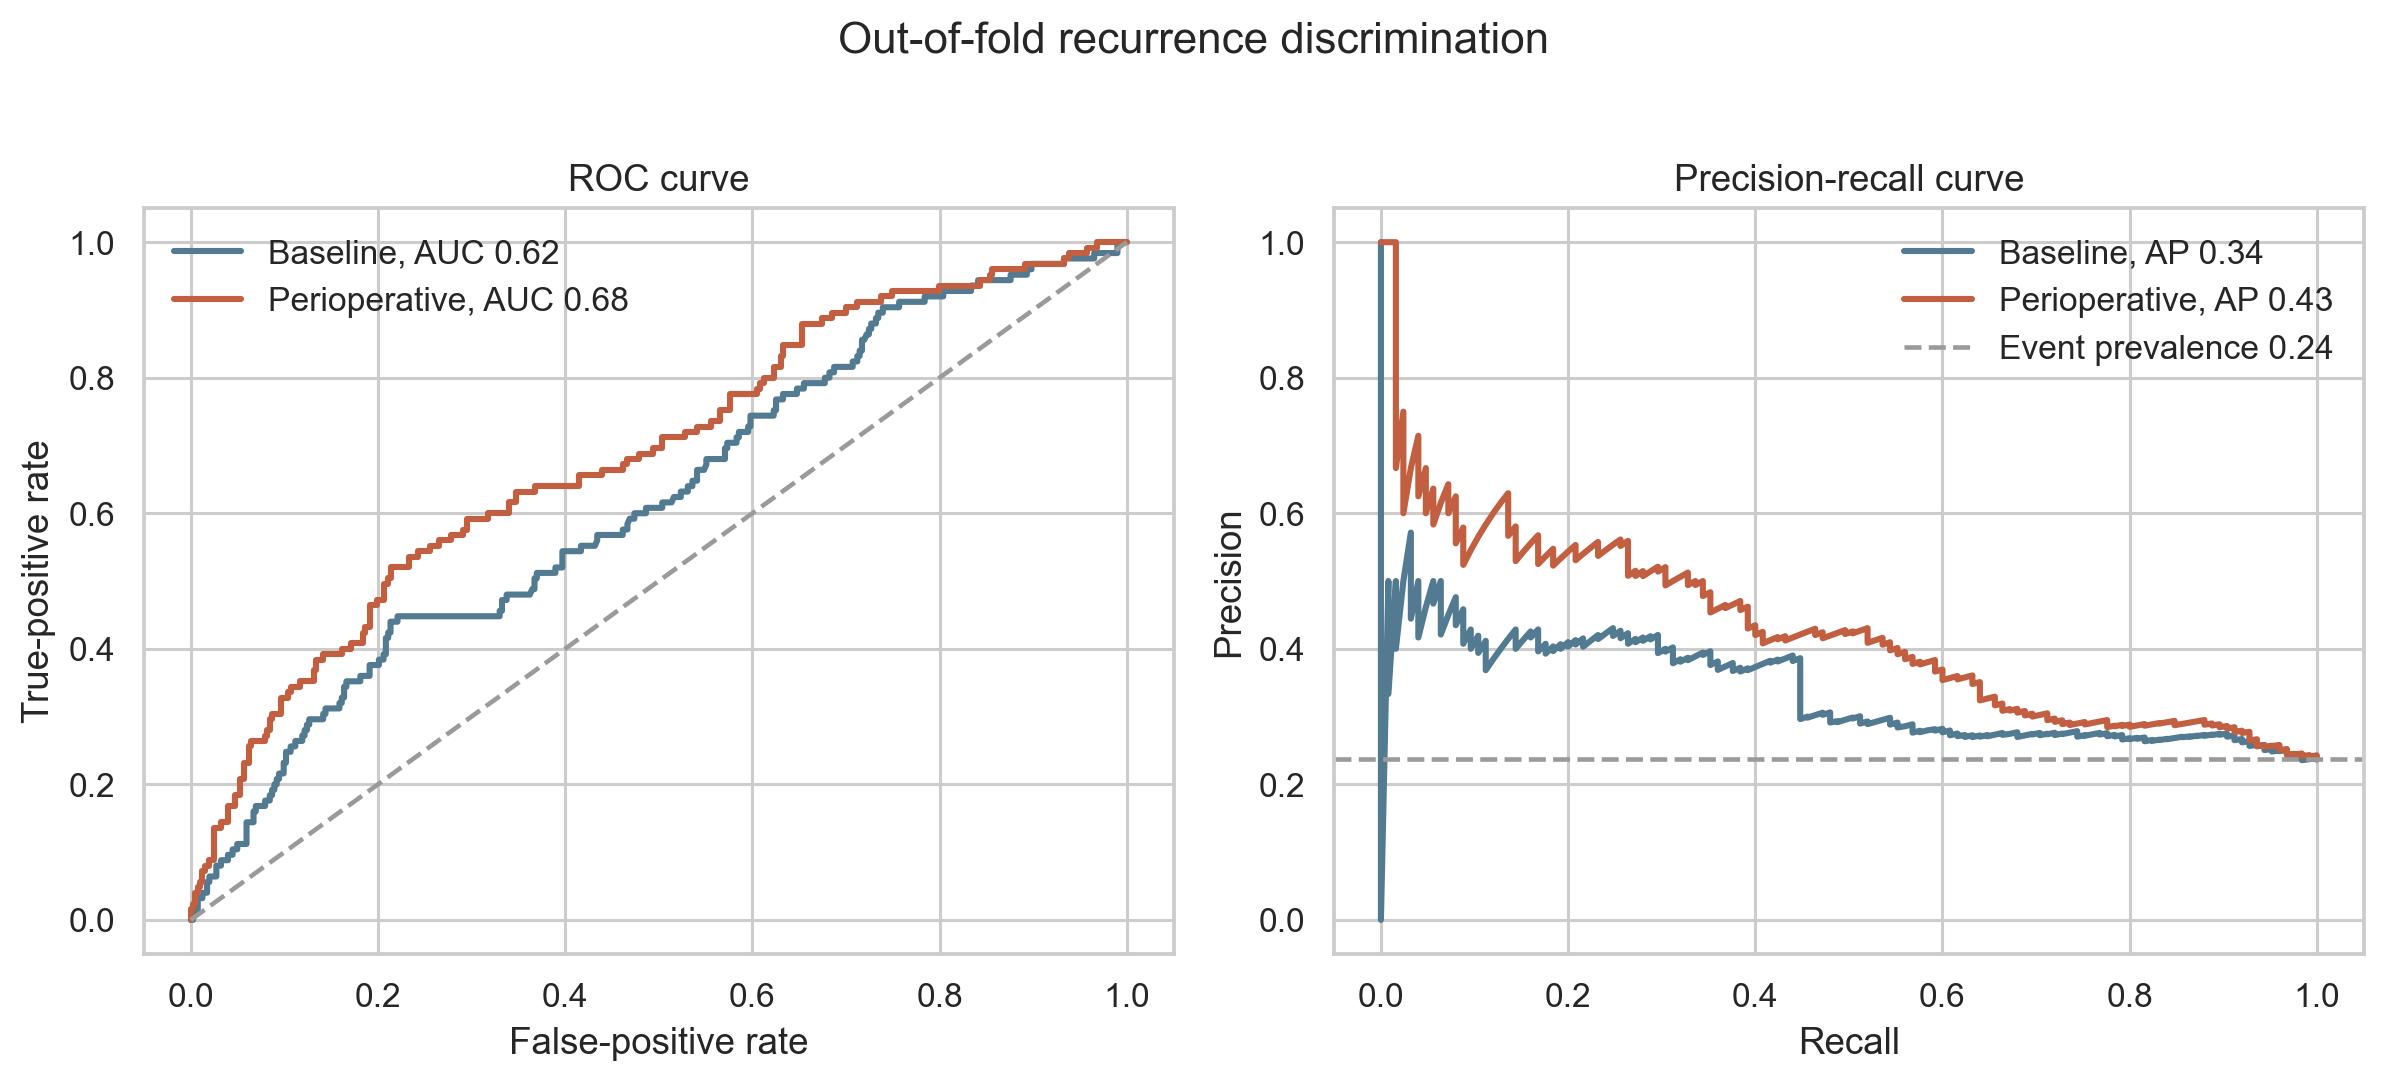

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
palette = {"Baseline": "#527b91", "Perioperative": "#c15f40"}

for model_name, probability in prediction_scores.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y, probability)
    precision, recall, _ = precision_recall_curve(y, probability)
    auc = roc_auc_score(y, probability)
    ap = average_precision_score(y, probability)
    axes[0].plot(false_positive_rate, true_positive_rate, label=f"{model_name}, AUC {auc:.2f}", color=palette[model_name], linewidth=2)
    axes[1].plot(recall, precision, label=f"{model_name}, AP {ap:.2f}", color=palette[model_name], linewidth=2)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="#9a9a9a")
axes[0].set_xlabel("False-positive rate")
axes[0].set_ylabel("True-positive rate")
axes[0].set_title("ROC curve")
axes[0].legend(frameon=False)

axes[1].axhline(y.mean(), linestyle="--", color="#9a9a9a", label=f"Event prevalence {y.mean():.2f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend(frameon=False)

fig.suptitle("Out-of-fold recurrence discrimination", y=1.02)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "06_prediction_discrimination.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "06_prediction_discrimination.png"), alt="Out-of-fold ROC and precision-recall curves for two recurrence models."))

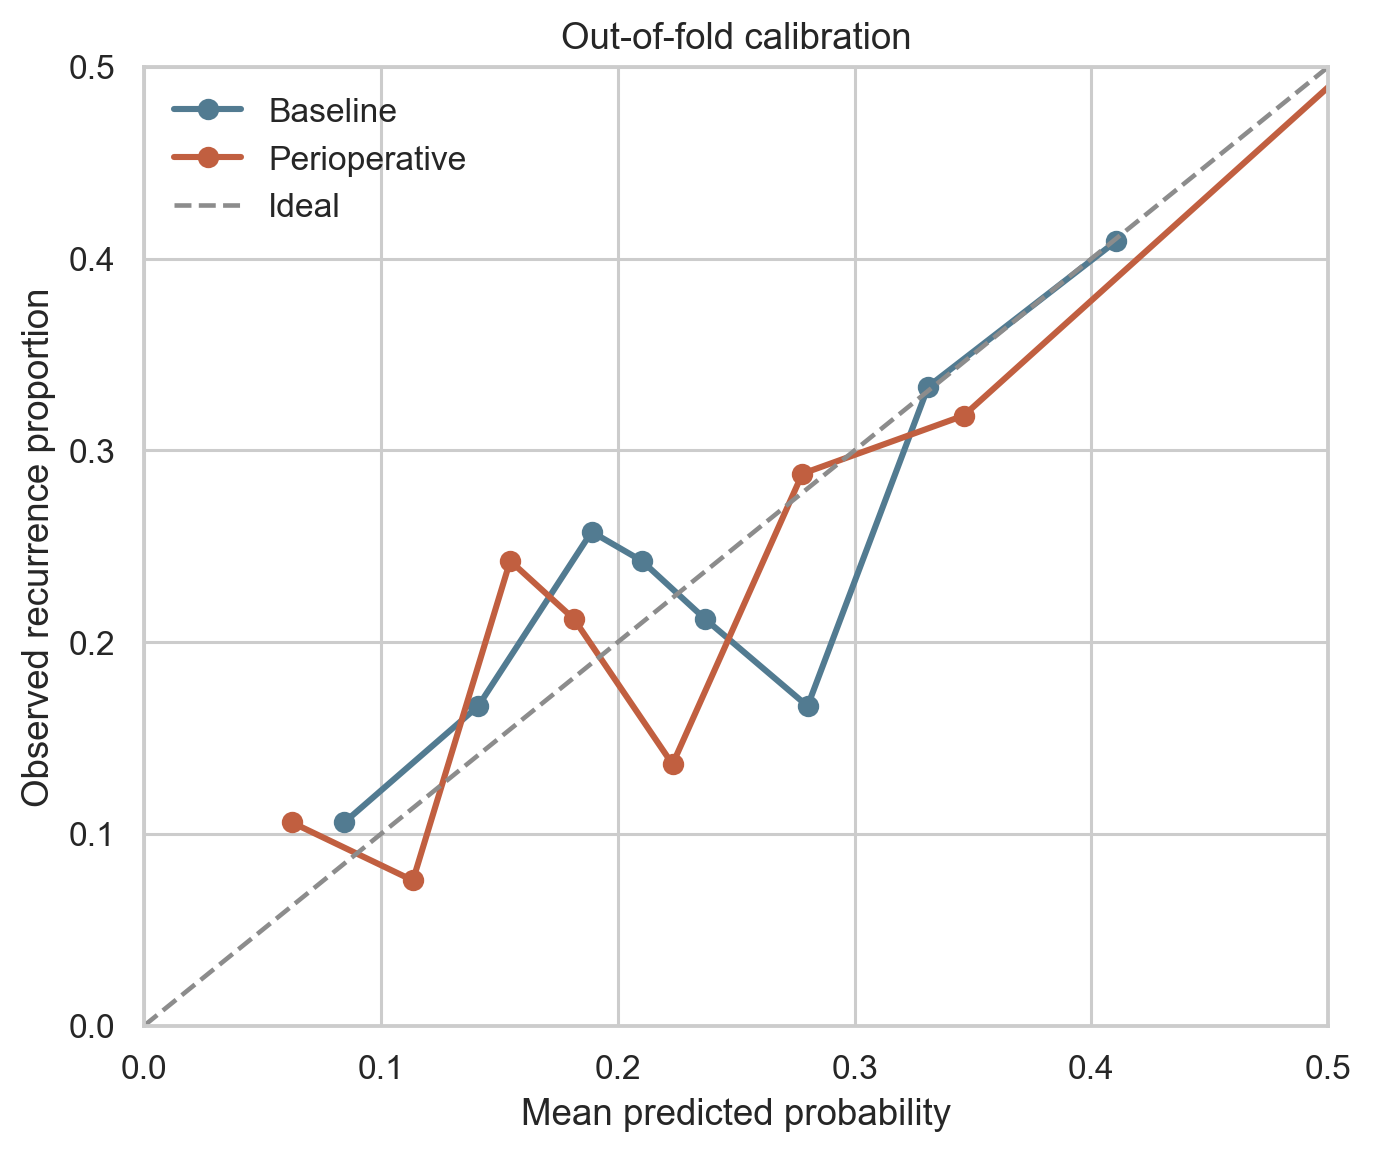

In [20]:
fig, axis = plt.subplots(figsize=(6.4, 5.4))
for model_name, probability in prediction_scores.items():
    observed, predicted = calibration_curve(y, probability, n_bins=8, strategy="quantile")
    axis.plot(predicted, observed, marker="o", label=model_name, color=palette[model_name], linewidth=2)
axis.plot([0, 0.50], [0, 0.50], linestyle="--", color="#8c8c8c", label="Ideal")
axis.set_xlim(0, 0.50)
axis.set_ylim(0, 0.50)
axis.set_xlabel("Mean predicted probability")
axis.set_ylabel("Observed recurrence proportion")
axis.set_title("Out-of-fold calibration")
axis.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "07_calibration.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "07_calibration.png"), alt="Out-of-fold calibration plot for two recurrence models."))

### Does the perioperative model improve AUC?

A paired bootstrap resamples records once per iteration and evaluates both models on the same resample. This preserves the pairing between predictions and yields an interval for the AUC difference. The comparison remains exploratory because the two models were developed and assessed in the same cohort.

In [21]:
local_rng = np.random.default_rng(SEED)
auc_differences = []
for _ in range(2000):
    index = local_rng.integers(0, len(y), len(y))
    if len(np.unique(y.iloc[index])) < 2:
        continue
    auc_differences.append(
        roc_auc_score(y.iloc[index], prediction_scores["Perioperative"][index])
        - roc_auc_score(y.iloc[index], prediction_scores["Baseline"][index])
    )

auc_differences = np.asarray(auc_differences)
observed_auc_difference = roc_auc_score(y, prediction_scores["Perioperative"]) - roc_auc_score(
    y, prediction_scores["Baseline"]
)
auc_comparison = pd.DataFrame(
    [
        {
            "comparison": "Perioperative minus baseline",
            "auc_difference": observed_auc_difference,
            "ci_low": np.quantile(auc_differences, 0.025),
            "ci_high": np.quantile(auc_differences, 0.975),
            "two_sided_bootstrap_p": 2
            * min(np.mean(auc_differences <= 0), np.mean(auc_differences >= 0)),
        }
    ]
)
auc_comparison.to_csv(TABLE_DIR / "09_auc_comparison.csv", index=False)
auc_comparison

,comparison,auc_difference,ci_low,ci_high,two_sided_bootstrap_p
0,Perioperative minus baseline,0.066,0.026,0.111,0.001


## Hospital stay as a count outcome

Hospital stay is modeled as a non-negative count. Pearson dispersion is checked before choosing a count model. The data do not show extra-Poisson variation, so a Poisson model with heteroskedasticity-consistent standard errors is retained. Exponentiated coefficients are incidence rate ratios. Values above 1 indicate a longer expected stay after adjustment.

In [22]:
los_formula = (
    "length_of_stay_days ~ indication_recurrence + previous_tube_thoracostomy + "
    "postop_air_leak_days + postop_complication + age_5y + sex_male + smoking_history"
)
poisson_initial = smf.glm(los_formula, data=df, family=sm.families.Poisson()).fit()
pearson_dispersion = float(np.sum(poisson_initial.resid_pearson**2) / poisson_initial.df_resid)
poisson_result = smf.glm(los_formula, data=df, family=sm.families.Poisson()).fit(cov_type="HC0")

los_terms = [term for term in poisson_result.params.index if term != "Intercept"]
los_table = regression_table(
    poisson_result,
    list(poisson_result.params.index),
    exponentiate=True,
)
los_table = los_table.loc[los_table["term"].isin(los_terms)].copy()
los_table.rename(columns={"estimate": "incidence_rate_ratio"}, inplace=True)
los_table.to_csv(TABLE_DIR / "10_length_of_stay_model.csv", index=False)
pd.DataFrame(
    [
        {
            "diagnostic": "Poisson Pearson dispersion",
            "value": pearson_dispersion,
            "interpretation": "No extra-Poisson variation detected" if pearson_dispersion <= 1.2 else "Extra-Poisson variation detected",
        }
    ]
).to_csv(TABLE_DIR / "10b_count_model_diagnostics.csv", index=False)
print(f"Poisson Pearson dispersion: {pearson_dispersion:.2f}")
los_table

Poisson Pearson dispersion: 0.14


,term,incidence_rate_ratio,ci_low,ci_high,p_value
1,indication_recurrence,0.990,0.958,1.023,0.561
2,previous_tube_thoracostomy,1.124,1.091,1.158,0.000
3,postop_air_leak_days,1.061,1.054,1.067,0.000
4,postop_complication,1.088,1.020,1.161,0.010
5,age_5y,0.994,0.978,1.010,0.432
6,sex_male,1.021,0.985,1.059,0.256
7,smoking_history,1.003,0.974,1.033,0.860


## Sensitivity analysis for unknown operative findings

The primary Cox model uses a separate indicator for an unknown bleb or bulla finding. Three alternatives are examined: complete-record analysis, treating unknown as not visualized, and treating unknown as visualized. Stability across these choices would suggest that the main conclusion is not driven by one missing-data convention.

In [23]:
base_adjustment = [
    "indication_recurrence",
    "age_5y",
    "sex_male",
    "smoking_history",
    "previous_tube_thoracostomy",
    "multiple_wedge",
]


def fit_bleb_sensitivity(frame, bleb_variable, additional=None):
    variables = [bleb_variable] + (additional or []) + base_adjustment
    model = PHReg(
        frame["time_to_event_months"],
        frame[variables].astype(float),
        status=frame["ipsilateral_recurrence"],
        ties="efron",
    ).fit()
    confidence = np.exp(np.asarray(model.conf_int())[0])
    return np.exp(model.params[0]), confidence[0], confidence[1], model.pvalues[0], len(frame)


sensitivity_rows = []

primary_frame = df.copy()
primary_frame["bleb_primary"] = primary_frame["bleb_not_visualized"].fillna(0)
estimate = fit_bleb_sensitivity(primary_frame, "bleb_primary", additional=["bleb_unknown"])
sensitivity_rows.append(("Primary, unknown indicator", *estimate))

complete_frame = df.loc[df["bleb_status"].ne("unknown")].copy()
complete_frame["bleb_complete"] = complete_frame["bleb_status"].eq("not_visualized").astype(int)
estimate = fit_bleb_sensitivity(complete_frame, "bleb_complete")
sensitivity_rows.append(("Known operative finding only", *estimate))

unknown_high = df.copy()
unknown_high["bleb_unknown_as_not_visualized"] = unknown_high["bleb_status"].ne("visualized").astype(int)
estimate = fit_bleb_sensitivity(unknown_high, "bleb_unknown_as_not_visualized")
sensitivity_rows.append(("Unknown treated as not visualized", *estimate))

unknown_low = df.copy()
unknown_low["bleb_unknown_as_visualized"] = unknown_low["bleb_status"].eq("not_visualized").astype(int)
estimate = fit_bleb_sensitivity(unknown_low, "bleb_unknown_as_visualized")
sensitivity_rows.append(("Unknown treated as visualized", *estimate))

sensitivity_table = pd.DataFrame(
    sensitivity_rows,
    columns=["analysis", "hazard_ratio", "ci_low", "ci_high", "p_value", "n"],
)
sensitivity_table.to_csv(TABLE_DIR / "11_sensitivity_analysis.csv", index=False)
sensitivity_table

,analysis,hazard_ratio,ci_low,ci_high,p_value,n
0,"Primary, unknown indicator",2.716,1.955,3.773,0.000,650
1,Known operative finding only,2.751,1.979,3.823,0.000,628
2,Unknown treated as not visualized,2.421,1.771,3.309,0.000,650
3,Unknown treated as visualized,2.682,1.935,3.717,0.000,650


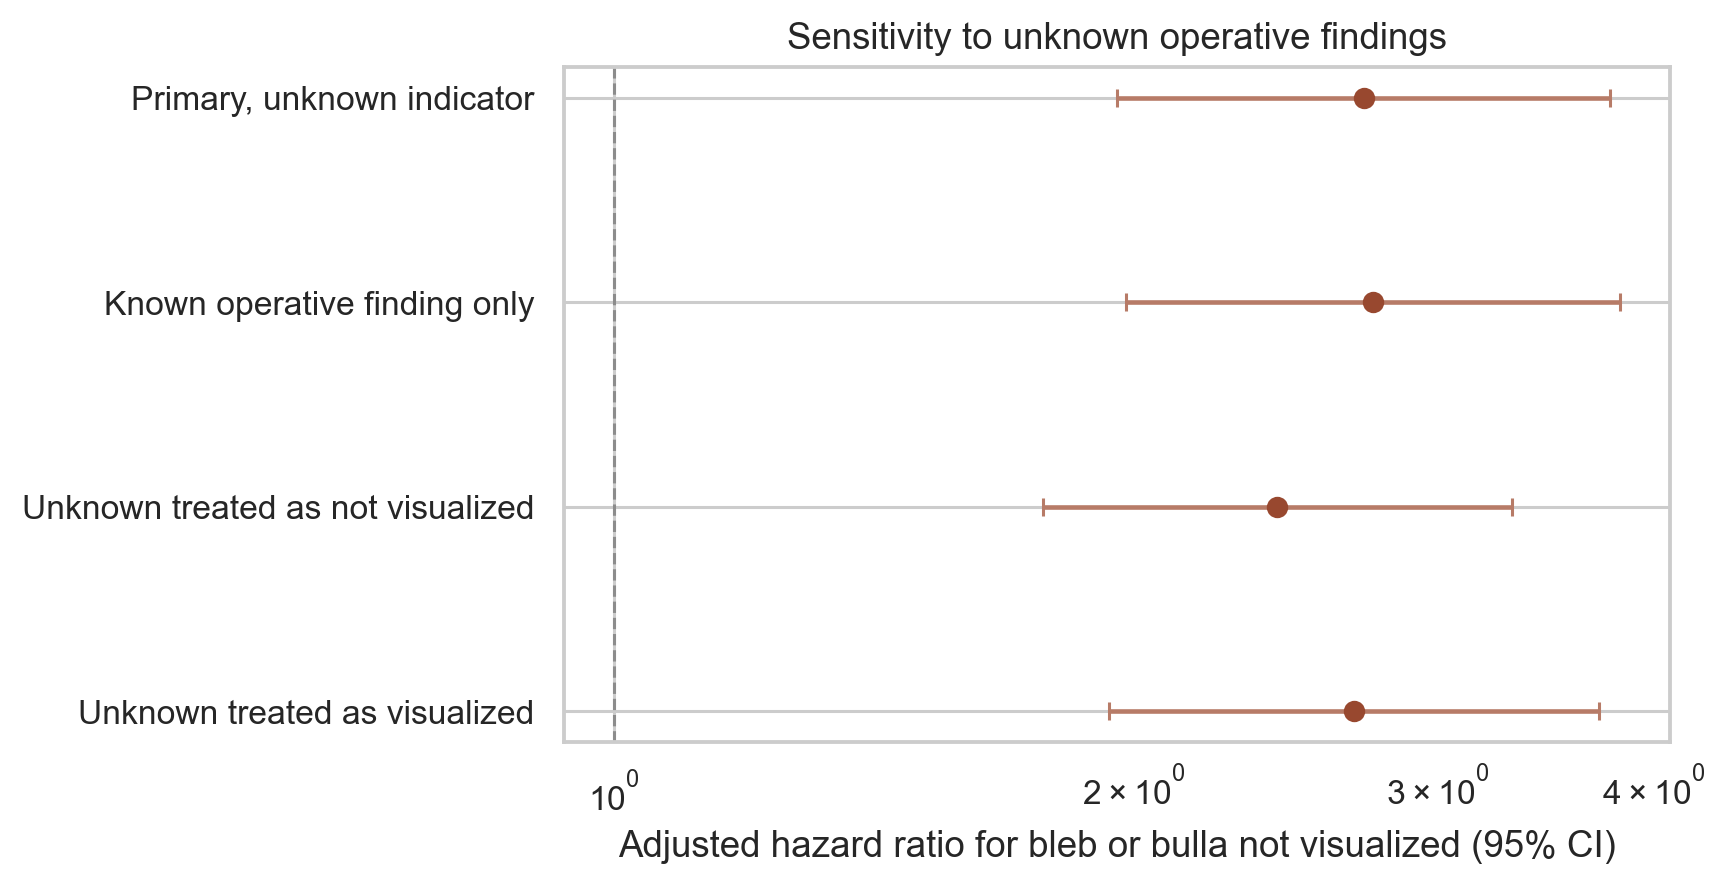

In [24]:
forest = sensitivity_table.iloc[::-1].reset_index(drop=True)
positions = np.arange(len(forest))
fig, axis = plt.subplots(figsize=(8, 4.2))
axis.errorbar(
    forest["hazard_ratio"],
    positions,
    xerr=[forest["hazard_ratio"] - forest["ci_low"], forest["ci_high"] - forest["hazard_ratio"]],
    fmt="o",
    color="#98482f",
    ecolor="#b77b67",
    capsize=3,
)
axis.axvline(1, color="#8c8c8c", linestyle="--", linewidth=1)
axis.set_xscale("log")
axis.set_yticks(positions, forest["analysis"])
axis.set_xlabel("Adjusted hazard ratio for bleb or bulla not visualized (95% CI)")
axis.set_title("Sensitivity to unknown operative findings")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "08_sensitivity_forest.png", dpi=220, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(FIGURE_DIR / "08_sensitivity_forest.png"), alt="Sensitivity-analysis forest plot for operative bleb finding."))

## Prospective planning

Future studies should be planned around the number of recurrence events, not only the total cohort size. Schoenfeld's approximation estimates the event count needed to detect a specified hazard ratio for a binary exposure. The total sample size then depends on the expected recurrence proportion.

These values are scenario estimates for planning. They are not retrospective power calculations and they do not rescue an imprecise result.

In [25]:
known_finding = df.loc[df["bleb_status"].ne("unknown")]
exposure_prevalence = known_finding["bleb_status"].eq("not_visualized").mean()
recurrence_proportion = df["ipsilateral_recurrence"].mean()

power_rows = []
for hazard_ratio in [1.50, 1.80, 2.00]:
    for target_power in [0.80, 0.90]:
        required_events = (
            (stats.norm.ppf(0.975) + stats.norm.ppf(target_power)) ** 2
            / ((np.log(hazard_ratio) ** 2) * exposure_prevalence * (1 - exposure_prevalence))
        )
        required_records = required_events / recurrence_proportion
        power_rows.append(
            {
                "target_hazard_ratio": hazard_ratio,
                "target_power": target_power,
                "two_sided_alpha": 0.05,
                "assumed_exposure_prevalence": exposure_prevalence,
                "assumed_recurrence_proportion": recurrence_proportion,
                "required_events": int(np.ceil(required_events)),
                "approximate_required_records": int(np.ceil(required_records)),
            }
        )

power_plan = pd.DataFrame(power_rows)
power_plan.to_csv(TABLE_DIR / "12_prospective_power_plan.csv", index=False)
power_plan

,target_hazard_ratio,target_power,two_sided_alpha,assumed_exposure_prevalence,assumed_recurrence_proportion,required_events,approximate_required_records
0,1.500,0.800,0.050,0.201,0.272,298,1094
1,1.500,0.900,0.050,0.201,0.272,399,1464
2,1.800,0.800,0.050,0.201,0.272,142,521
3,1.800,0.900,0.050,0.201,0.272,190,697
4,2.000,0.800,0.050,0.201,0.272,102,375
5,2.000,0.900,0.050,0.201,0.272,137,501


## Interpretation boundaries

- The group comparisons describe an observational cohort and do not estimate causal effects.
- The Cox model accounts for censoring but cannot remove unmeasured confounding.
- The prediction models receive internal, out-of-fold evaluation only. External validation would be required before clinical use.
- The event count limits the complexity of recurrence modeling. Estimates and intervals are more informative than isolated p-values.
- Missingness is handled explicitly for operative findings and by within-fold imputation in prediction models.

The most defensible reading is a demonstration of a complete clinical analysis workflow. It moves from data quality and description to uncertainty, adjusted time-to-event analysis, prediction, sensitivity analysis, and planning.

In [26]:
session_info = {
    "python": platform.python_version(),
    "platform": platform.platform(),
    "random_seed": SEED,
    "records": len(df),
    "events": int(df["ipsilateral_recurrence"].sum()),
    "packages": {
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scipy": scipy.__version__,
    },
}
with open(TABLE_DIR / "session_info.json", "w", encoding="utf-8") as file:
    json.dump(session_info, file, indent=2)
session_info

{'python': '3.11.15',
 'platform': 'macOS-26.6.2-arm64-arm-64bit',
 'random_seed': 20260915,
 'records': 650,
 'events': 177,
 'packages': {'numpy': '2.4.3', 'pandas': '2.3.3', 'scipy': '1.17.1'}}